# SOLA Method with Noise: Property Inference from Noisy Observations

## The Continuous Problem

We address the task of estimating a finite‐dimensional property of an unknown model from noisy observations. This is a classic problem in inverse theory where we seek to infer localized properties without explicitly reconstructing the full model.

Let $m \in \mathcal{M}$ be the unknown model in a separable Hilbert space, $\mathbf{\tilde{d}} \in \mathcal{D} \cong \mathbb{R}^{N_d}$ be the observed data, and $\mathbf{\tilde{p}} \in \mathcal{P} \cong \mathbb{R}^{N_p}$ be the desired properties, where $\mathcal{D}$ and $\mathcal{P}$ are Euclidean spaces of dimensions $N_d$ and $N_p$ respectively.

### Forward Operator and Data Model

The forward map is a bounded linear operator:
$$
G:\mathcal{M}\to \mathcal{D}, \qquad [G(m)]_i = \langle K_i, m \rangle_{\mathcal{M}}
$$

where $K_i \in \mathcal{M}$ are sensitivity kernels. The observed data is modeled as:
$$
\mathbf{\tilde{d}} = G(\bar{m}) + \bm{\eta}
$$

where $\bar{m}$ is the true (unknown) model and $\bm{\eta}$ represents additive noise. We model the data with a Gaussian measure:
$$
\mu_{\mathcal{D}} = \mathcal{N}(\mathbf{\tilde{d}}, \mathbf{C}_{\mathcal{D}})
$$

### Property Extraction

Similarly, the property of interest is extracted via:
$$
\mathcal{T}:\mathcal{M}\to \mathcal{P}, \qquad [\mathcal{T}(m)]_k = \langle T^{(k)}, m \rangle_{\mathcal{M}}
$$

where $T^{(k)} \in \mathcal{M}$ are the target kernels. Our ultimate goal is to recover:
$$
\bar{\mathbf{p}} = \mathcal{T}(\bar{m})
$$

### SOLA Approach

Since the inverse problem is ill‐posed, we do not attempt to reconstruct $\bar{m}$ directly. Instead, we seek a surrogate operator:
$$
\mathbf{X}:\mathcal{D} \to \mathcal{P}
$$

that approximates the composition $\mathcal{T} \circ G^{-1}$ on the most probable models. We enforce:
$$
\mathcal{T} \approx \mathbf{X}G
$$

and measure the discrepancy in the Hilbert–Schmidt norm while minimizing property uncertainty.

## SOLA Optimization Problem

We seek $\mathbf{X}$ as the solution to:
$$
\boxed{
\min_{\mathbf{X}} \left[ \|\mathcal{T} - \mathbf{X}G\|_{HS}^2 + \text{Tr}(\mathbf{X} \mathbf{C}_{\mathcal{D}} \mathbf{X}^*) \right]
}
$$

where $\|A\|_{HS}^2 = \text{Tr}(A A^*)$ is the Hilbert–Schmidt norm.

### Analytical Solution

The optimal operator is:
$$
\boxed{
\mathbf{X} = \mathcal{T} G^*(GG^* + \mathbf{C}_{\mathcal{D}})^{-1}
}
$$

### Property Measure

From this, we obtain the property measure by pushing forward the data measure:
$$
\mu_{\mathcal{P}} = \mathbf{X}_* \mu_{\mathcal{D}} = \mathcal{N}(\mathbf{\tilde{p}}, \mathbf{C}_{\mathcal{P}})
$$

where:
- **Property mean**: $\mathbf{\tilde{p}} = \mathbf{X}(\mathbf{\tilde{d}})$
- **Property covariance**: $\mathbf{C}_{\mathcal{P}} = \mathbf{X} \mathbf{C}_{\mathcal{D}} \mathbf{X}^*$

In [1]:
from intervalinf.providers import NormalModesProvider, BumpFunctionProvider, NullFunctionProvider
from intervalinf import IntervalDomain, Lebesgue, Sobolev, BoundaryConditions, SobolevSpaceDirectSum, Function
from intervalinf.operators import SOLAOperator, Laplacian
from pygeoinf import EuclideanSpace, LinearOperator, CholeskySolver, GaussianMeasure, RowLinearOperator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set-up folder for saving figures
import os
figures_folder = 'sola_noise_sobolev_multiple_figures'
if not os.path.exists(figures_folder):
    os.makedirs(figures_folder)


## Creating the Spaces

We first create the function domain as an interval $[0,1]$. The model space will be a **direct sum of two Sobolev spaces** $H^s([0,1])$ with $s=1$, representing smoothness regularization for two different physical parameters (e.g., $v_p$ and $v_s$ velocities).

The Sobolev norm provides:
- **Smoothness control**: Through the parameter $s$, controlling derivative regularity
- **Scale parameter**: Through $k$, balancing between L² and derivative components

We also define the data space $\mathcal{D} \cong \mathbb{R}^{N_d}$ and property space $\mathcal{P} \cong \mathbb{R}^{N_p}$ as finite-dimensional Euclidean spaces.

The model space is:
$$\mathcal{M} = H^s([0,1]) \oplus H^s([0,1])$$

In [2]:
# Create a function domain and spaces
function_domain = IntervalDomain(0, 1)

# Create Laplacian operator for Sobolev spaces
M_laplacian = Lebesgue(0, function_domain, basis=None)
bcs = BoundaryConditions(bc_type='dirichlet')
laplacian = Laplacian(M_laplacian, bcs, 1.0, method='spectral', dofs=100)

# Sobolev space parameters
s, k, L = 1, 10, laplacian

# Create two Sobolev spaces WITHOUT BASIS - we'll use LinearFormKernel for integration
M_vp = Sobolev(0, function_domain, s, k, L, basis=None)
M_vs = Sobolev(0, function_domain, s, k, L, basis=None)

# Use SobolevSpaceDirectSum instead of HilbertSpaceDirectSum
# This uses LinearFormKernel to avoid basis-dependent operations
M = SobolevSpaceDirectSum([M_vp, M_vs])

# Data and property spaces
N_d = 100  # number of data points
D = EuclideanSpace(N_d)  # data space
N_p = 20  # number of property points
P = EuclideanSpace(N_p)  # property space

print(f"Model space: Direct sum of two Sobolev({s}, {k}) spaces")
print(f"Model space dimension: {M.dim}")
print(f"Data space dimension: {D.dim}")
print(f"Property space dimension: {P.dim}")
print(f"Basis: None (using LinearFormKernel for integration-based operations)")


Model space: Direct sum of two Sobolev(1, 10) spaces
Model space dimension: 0
Data space dimension: 100
Property space dimension: 20
Basis: None (using LinearFormKernel for integration-based operations)


## Create Mappings

We now create the linear operators that define our problem:

1. **Forward operator $G$**: Maps from model space to data space using normal mode sensitivity kernels
2. **Target operator $\mathcal{T}$**: Maps from model space to property space using localized bump function kernels

The sensitivity kernels determine how sensitive each measurement is to different parts of the model, while the target kernels define the spatial localization of the properties we want to infer.

In [3]:
# Create forward and property mappings
width = 0.2  # width of the bump target functions
centers = np.linspace(function_domain.a + width / 2, function_domain.b - width / 2, N_p)

# Create separate normal modes providers for vp and vs
# Note: The random_state is set to ensure reproducibility of results
normal_modes_provider_vp = NormalModesProvider(
    M_vp,
    n_modes_range=(1, 50),
    coeff_range=(-5, 5),
    gaussian_width_percent_range=(1, 5),
    freq_range=(0.1, 20),
    random_state=2,
)
normal_modes_provider_vs = NormalModesProvider(
    M_vs,
    n_modes_range=(1, 50),
    coeff_range=(-5, 5),
    gaussian_width_percent_range=(1, 5),
    freq_range=(0.1, 20),
    random_state=3,
)

# Create forward operators for each component
G_vp = SOLAOperator(M_vp, D, kernels=normal_modes_provider_vp)
G_vs = SOLAOperator(M_vs, D, kernels=normal_modes_provider_vs)

# Combine into row operator (maps from direct sum to data space)
G = RowLinearOperator([G_vp, G_vs])

# Create target operators: bump functions for vp, null for vs
target_provider_vp = BumpFunctionProvider(M_vp, centers=centers, default_width=width)
target_provider_vs = NullFunctionProvider(M_vs)  # No target for vs

T_vp = SOLAOperator(M_vp, P, kernels=target_provider_vp)
T_vs = SOLAOperator(M_vs, P, kernels=target_provider_vs)

# Combine into row operator (maps from direct sum to property space)
T = RowLinearOperator([T_vp, T_vs])

print("Forward operator G: Sobolev Direct Sum → Data")
print("Target operator T: Sobolev Direct Sum → Property")
print(f"G has {N_d} sensitivity kernels")
print(f"T has {N_p} target kernels")


Forward operator G: Sobolev Direct Sum → Data
Target operator T: Sobolev Direct Sum → Property
G has 100 sensitivity kernels
T has 20 target kernels


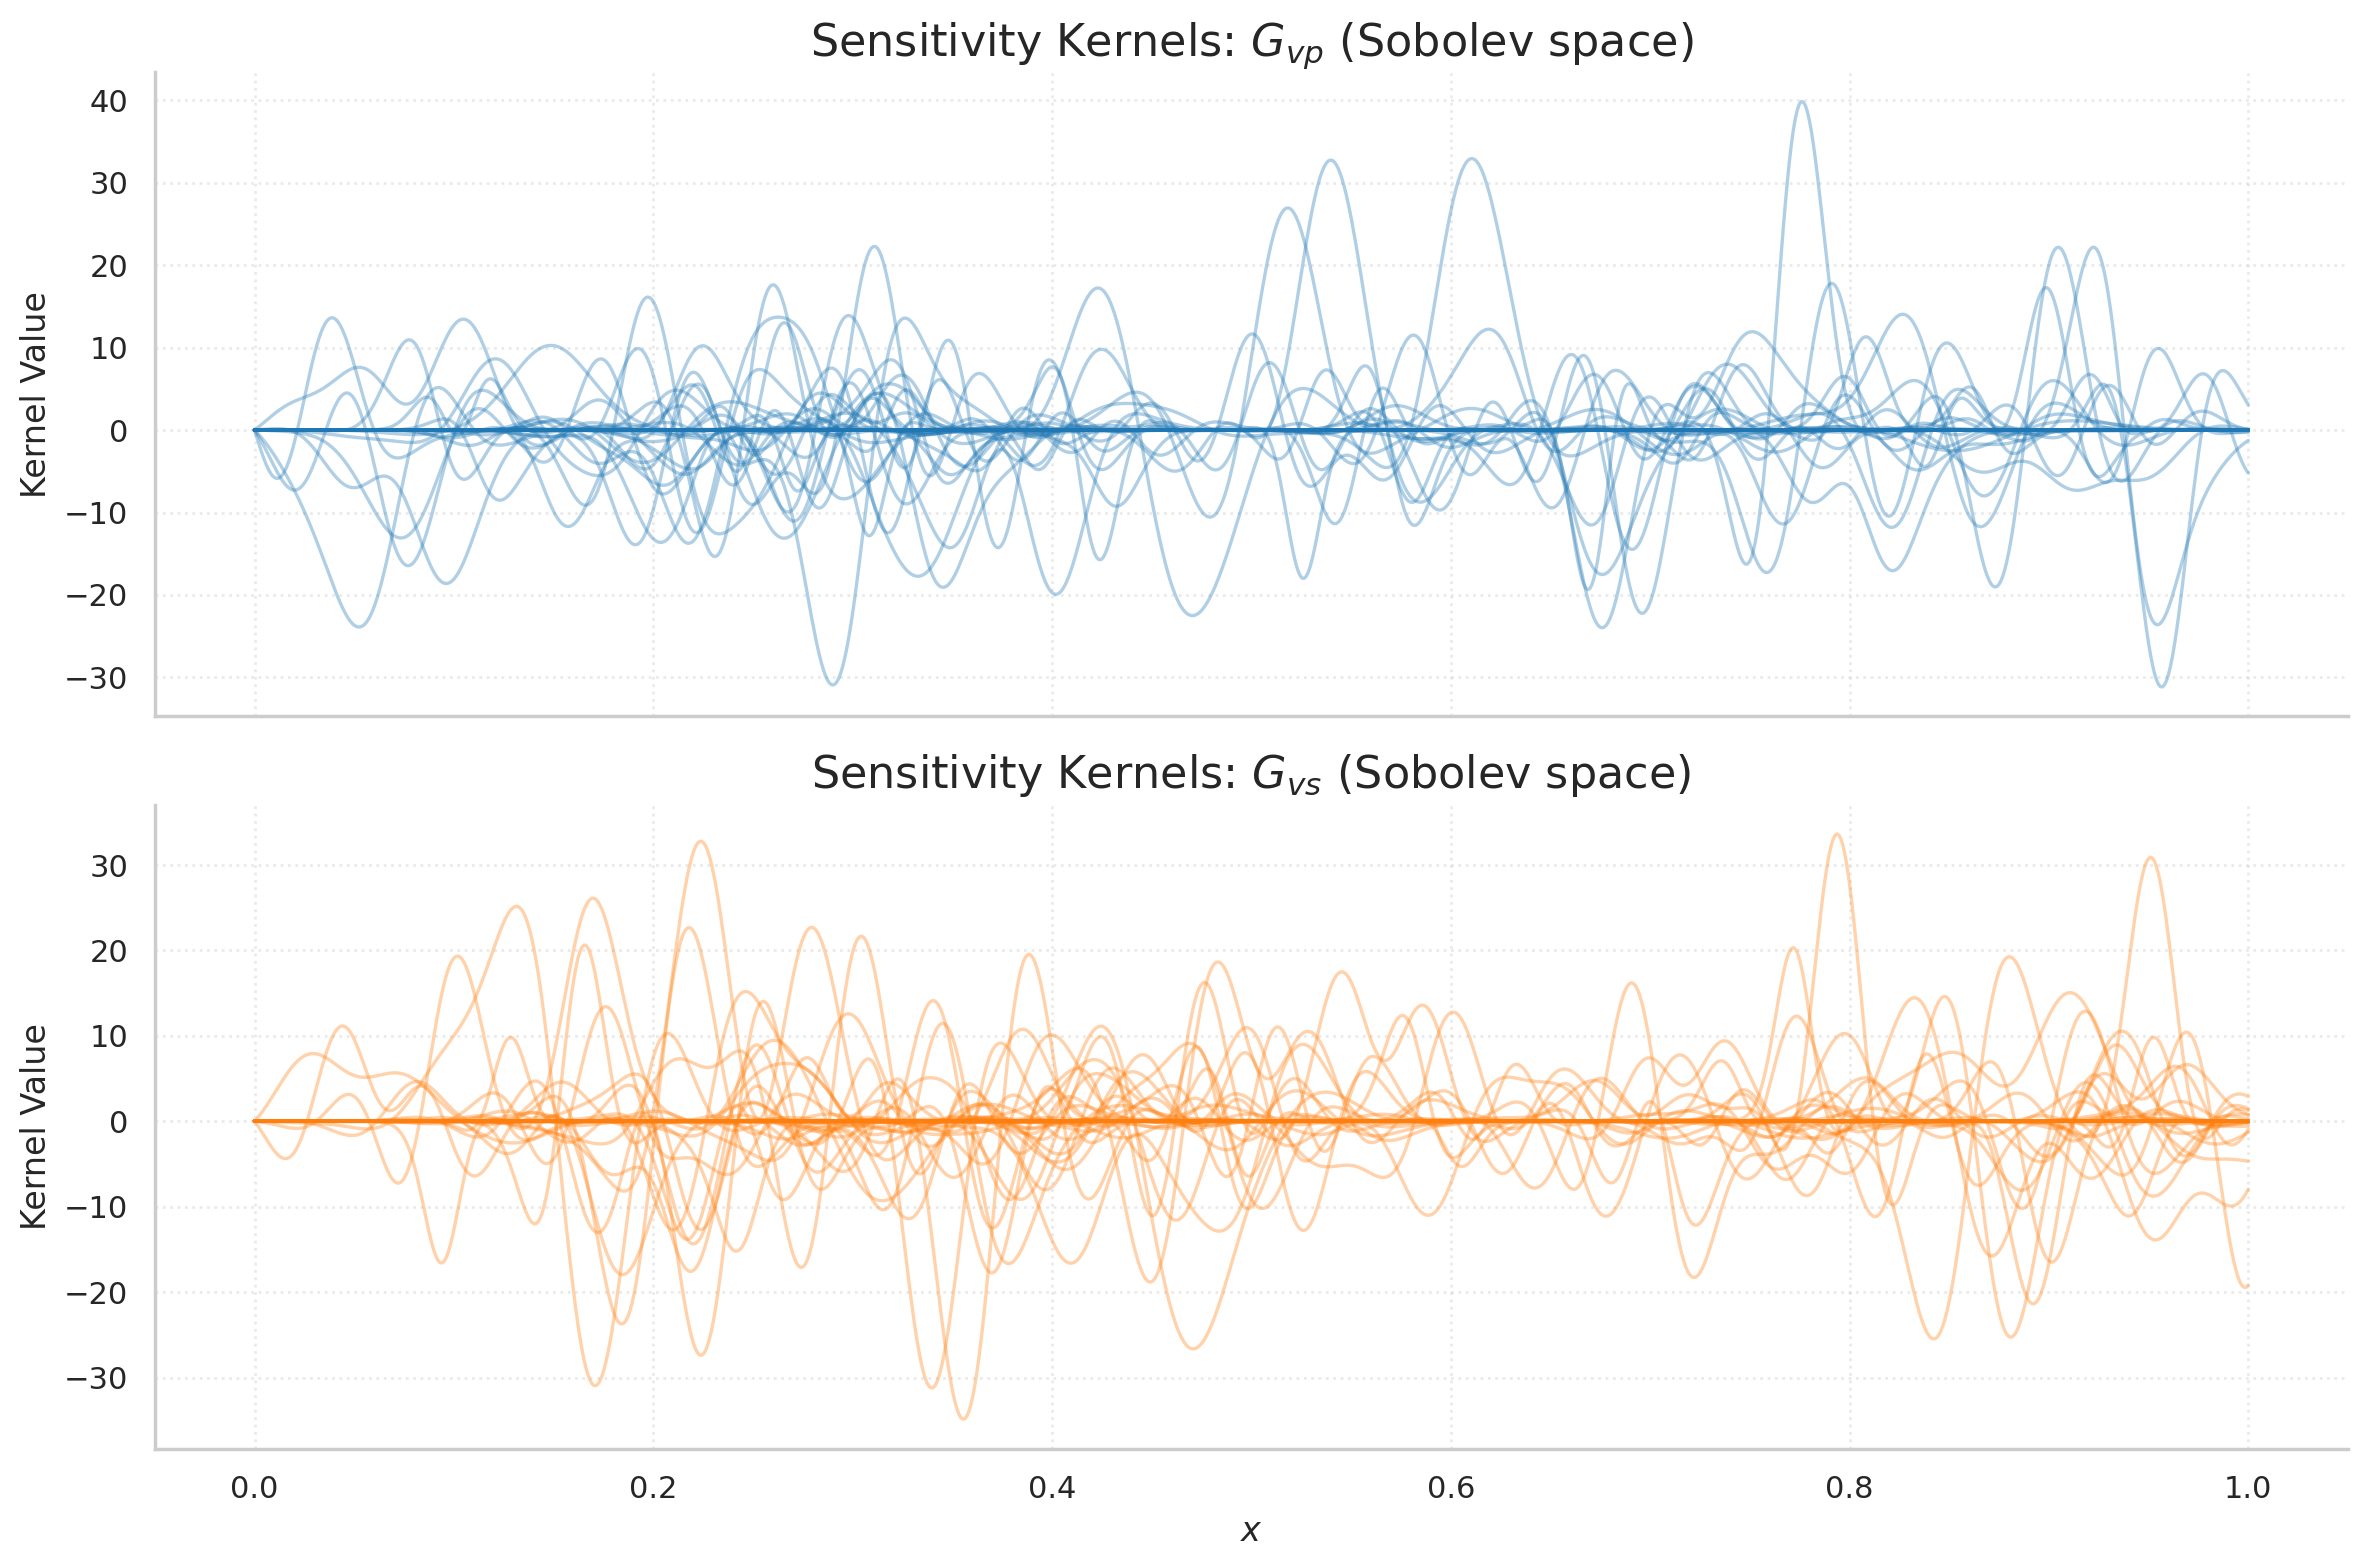

In [4]:
# Sensitivity Kernels figure (vp & vs)
fig_title = "Sensitivity Kernels (vp & vs)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

x = np.linspace(function_domain.a, function_domain.b, 1000)

sns.set_theme(style="whitegrid", palette="muted", color_codes=True)

# Create two vertically stacked subplots: top for G_vp, bottom for G_vs
fig, axs = plt.subplots(2, 1, figsize=(12, 8), dpi=200, sharex=True)

# Top subplot: G_vp kernels
axs[0].set_title(r"Sensitivity Kernels: $G_{vp}$ (Sobolev space)", fontsize=16)
for i in range(N_d):
    axs[0].plot(
        x,
        G_vp.get_kernel(i).evaluate(x),
        color='tab:blue',
        alpha=0.35,
        linewidth=1.2,
    )
axs[0].set_ylabel("Kernel Value", fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.4)

# Bottom subplot: G_vs kernels
axs[1].set_title(r"Sensitivity Kernels: $G_{vs}$ (Sobolev space)", fontsize=16)
for i in range(N_d):
    axs[1].plot(
        x,
        G_vs.get_kernel(i).evaluate(x),
        color='tab:orange',
        alpha=0.35,
        linewidth=1.2,
    )
axs[1].set_xlabel(r"$x$", fontsize=12)
axs[1].set_ylabel("Kernel Value", fontsize=12)
axs[1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()

# Save as both PNG and PDF for publication
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

### Sensitivity Kernels Analysis

The sensitivity kernels $K_i(x)$ define how sensitive each data point $d_i$ is to the model $m(x)$ at different spatial locations. These kernels are crucial for understanding:

- **Coverage**: Where in the domain we have observational sensitivity
- **Resolution**: How localized our measurements are  
- **Redundancy**: Overlapping kernels indicate multiple measurements of similar information

Regions where many kernels overlap (appearing darker) represent areas of high observational density, while sparse regions indicate limited sensitivity.

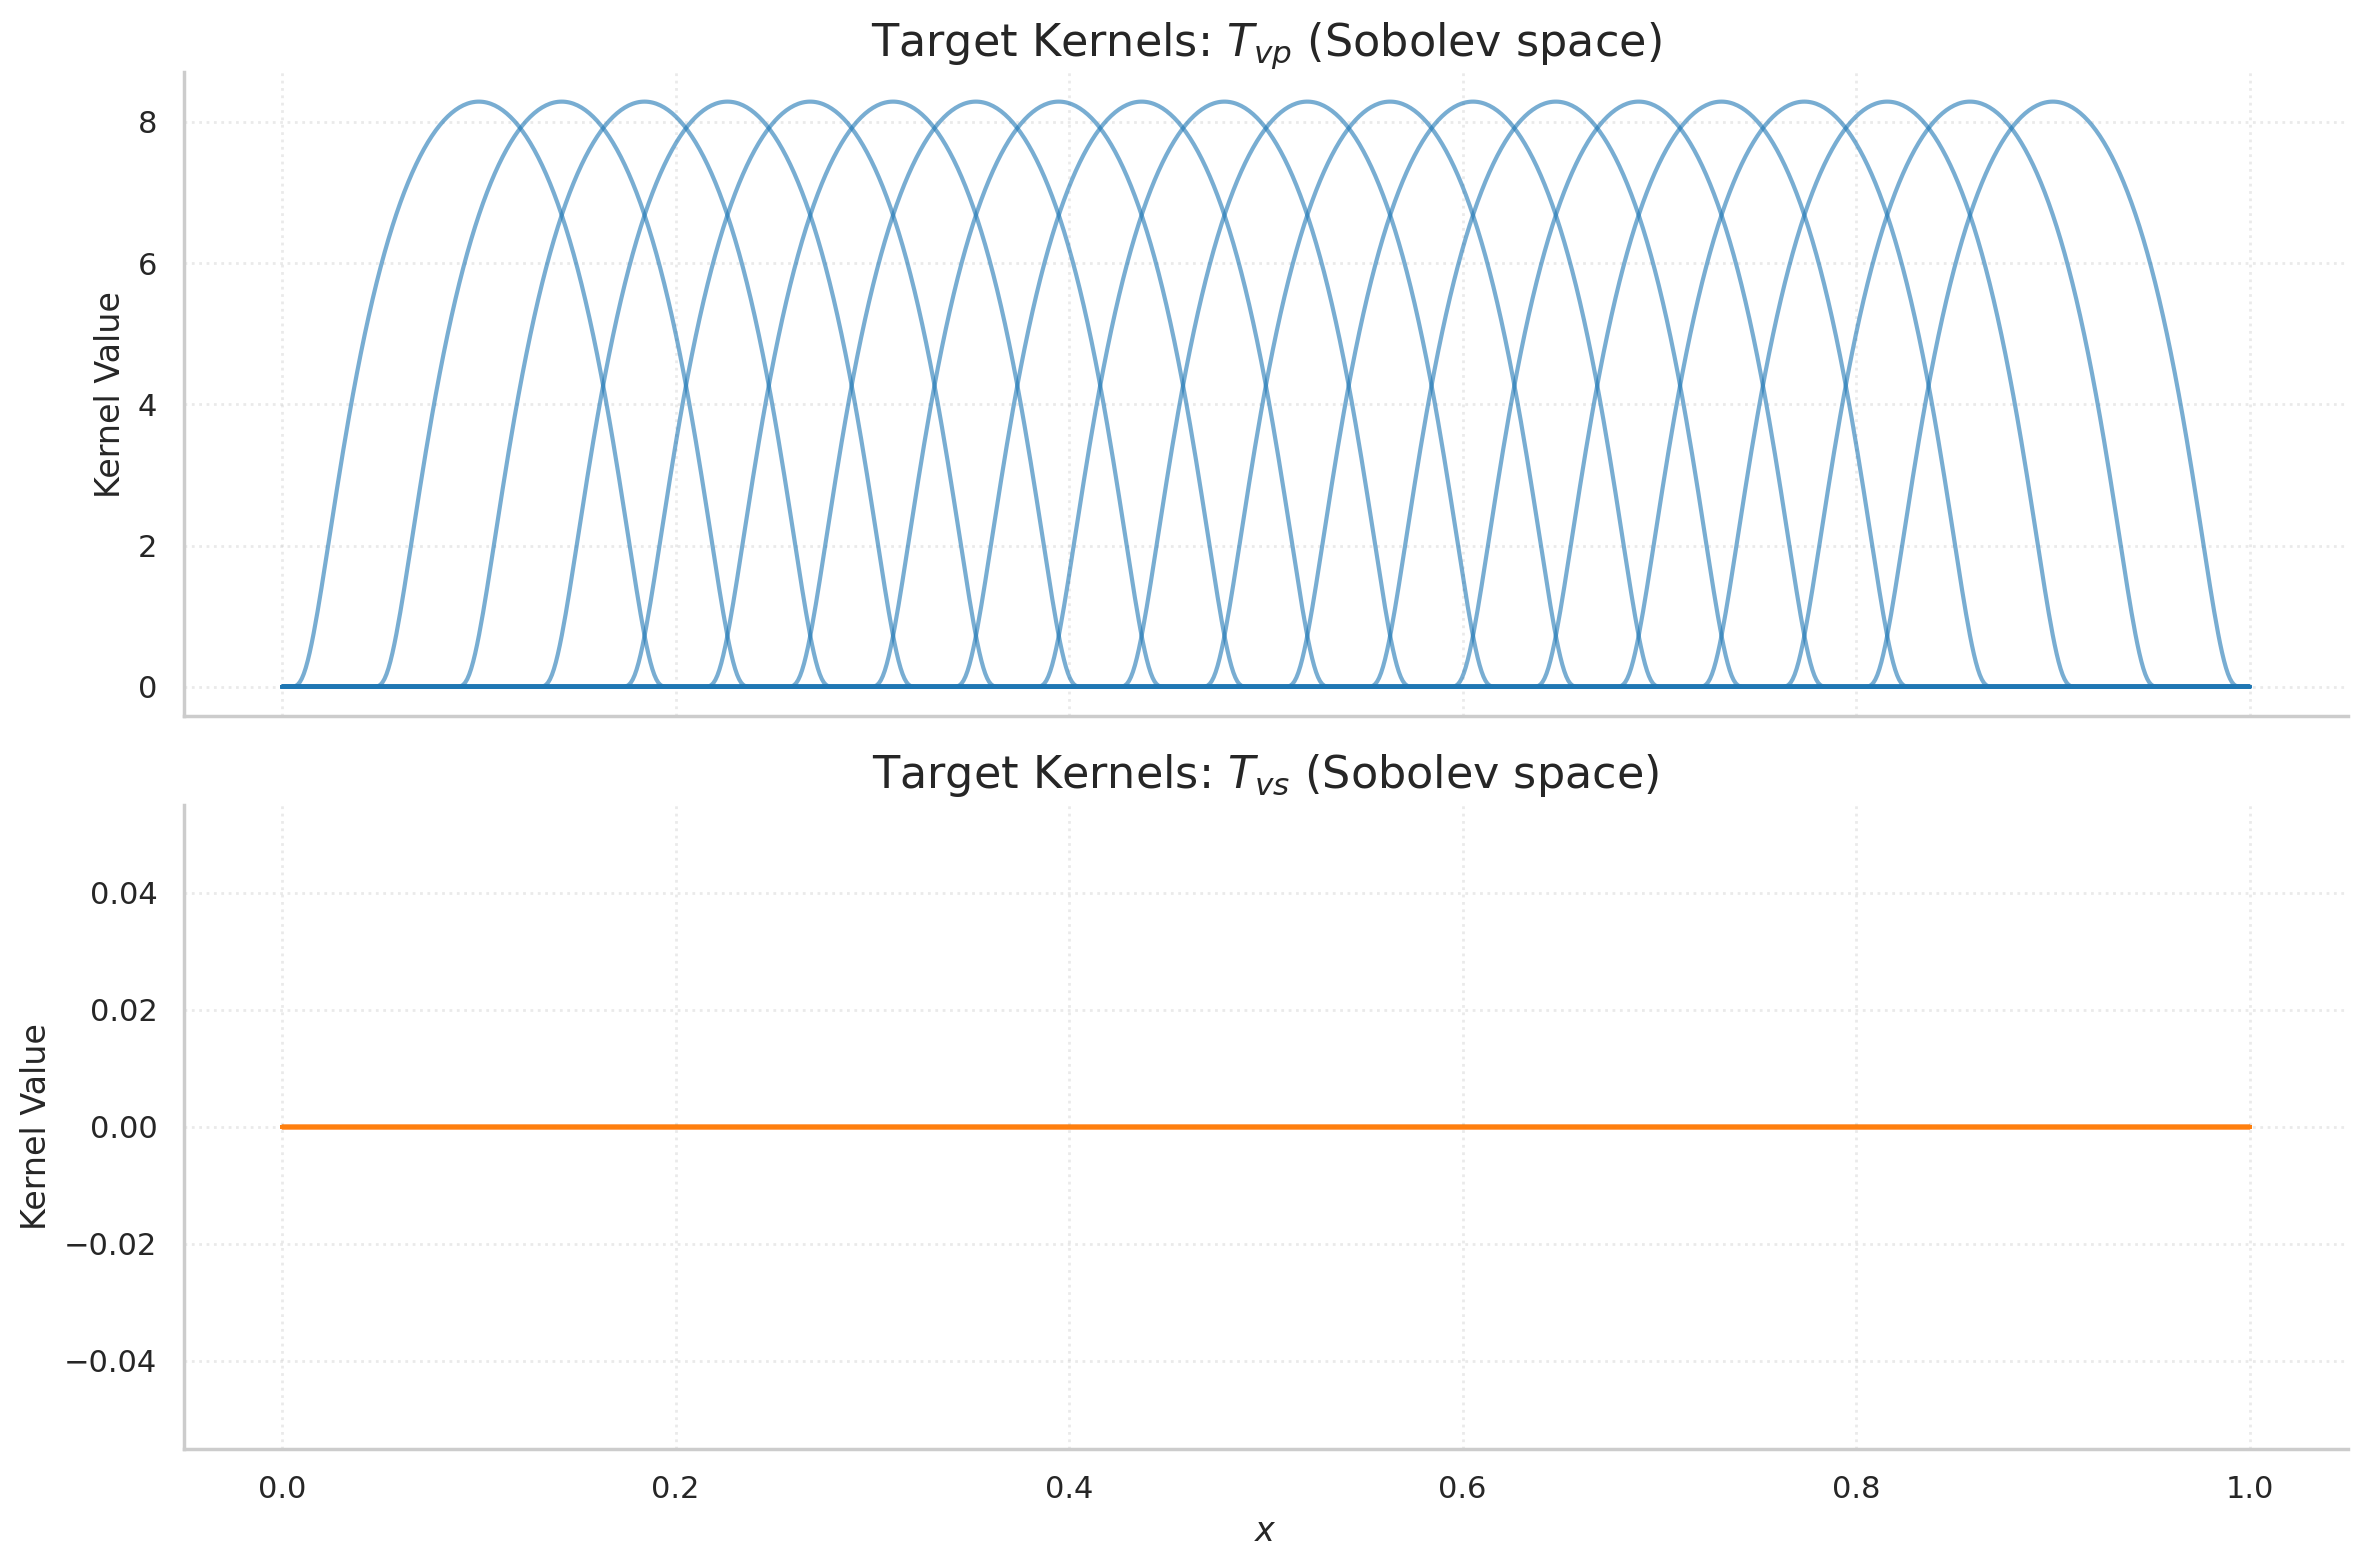

In [5]:
# Target Kernels figure (vp & vs)
fig_title = "Target Kernels (vp & vs)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

x = np.linspace(function_domain.a, function_domain.b, 1000)

sns.set_theme(style="whitegrid", palette="muted", color_codes=True)

# Two vertically stacked subplots: top for T_vp, bottom for T_vs
fig, axs = plt.subplots(2, 1, figsize=(12, 8), dpi=200, sharex=True)

# Top: T_vp
axs[0].set_title(r"Target Kernels: $T_{vp}$ (Sobolev space)", fontsize=16)
for i in range(N_p):
    axs[0].plot(
        x,
        T_vp.get_kernel(i).evaluate(x),
        color='tab:blue',
        alpha=0.6,
        linewidth=1.5,
    )
axs[0].set_ylabel("Kernel Value", fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.4)

# Bottom: T_vs (should be zero)
axs[1].set_title(r"Target Kernels: $T_{vs}$ (Sobolev space)", fontsize=16)
for i in range(N_p):
    axs[1].plot(
        x,
        T_vs.get_kernel(i).evaluate(x),
        color='tab:orange',
        alpha=0.6,
        linewidth=1.5,
    )
axs[1].set_xlabel(r"$x$", fontsize=12)
axs[1].set_ylabel("Kernel Value", fontsize=12)
axs[1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()

# Save as both PNG and PDF
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

### Target Kernels for Property Extraction

The target kernels $T^{(k)}(x)$ define the properties we want to infer about the model. Each kernel extracts a local average of the model around its center location. These bump functions allow us to:

- **Localize**: Extract spatially localized properties
- **Regularize**: Smooth local estimates through spatial averaging
- **Focus**: Target specific regions of interest in the domain

The width of each bump determines the spatial resolution of the property extraction - narrower bumps give higher spatial resolution but may be more sensitive to noise.

## Synthetic Data Generation

### True Model Construction

We create a synthetic "true" model $\bar{m}(x)$ to test our SOLA method:

$$\bar{m}(x) = \sin(2\pi x)$$

This simple sinusoidal model provides a smooth, oscillatory function that will test our ability to recover localized properties from noisy observations.

From this true model, we generate synthetic observations $\mathbf{\bar{d}} = G(\bar{m})$ and add noise to create realistic measurements $\mathbf{\tilde{d}}$.

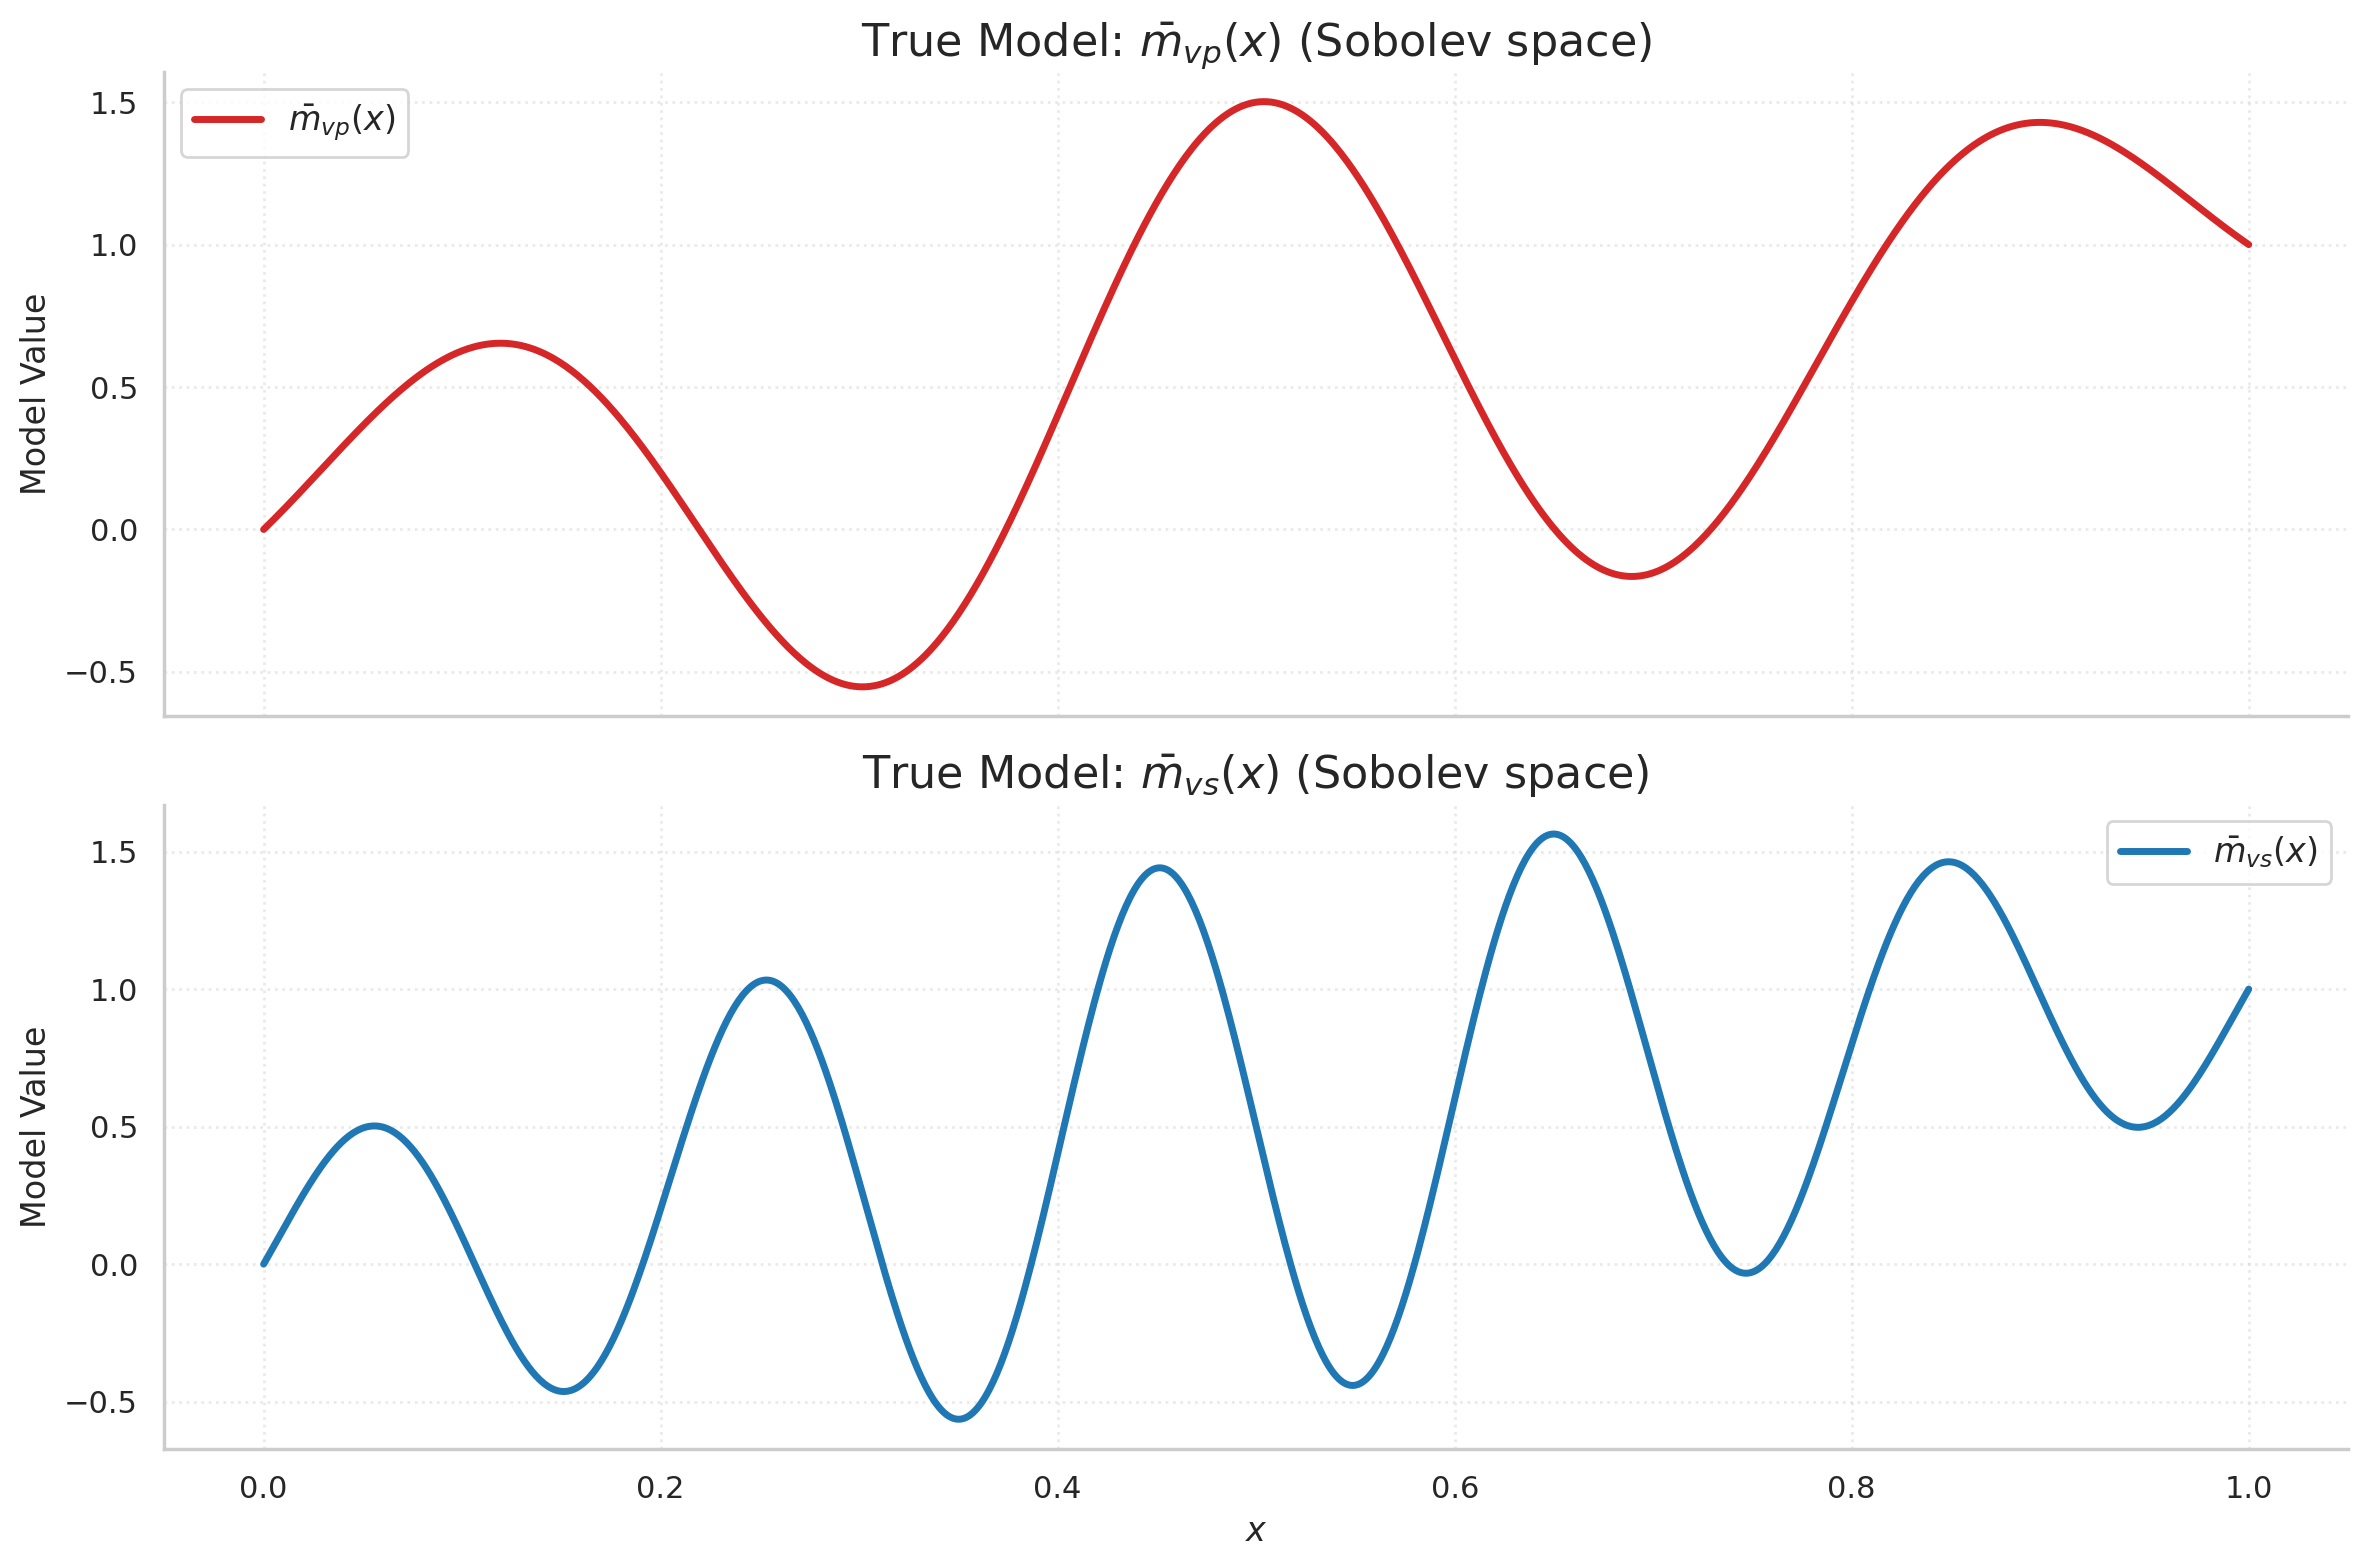

Generating synthetic data...
Signal-to-noise ratio: 10.0
Number of observations: 100


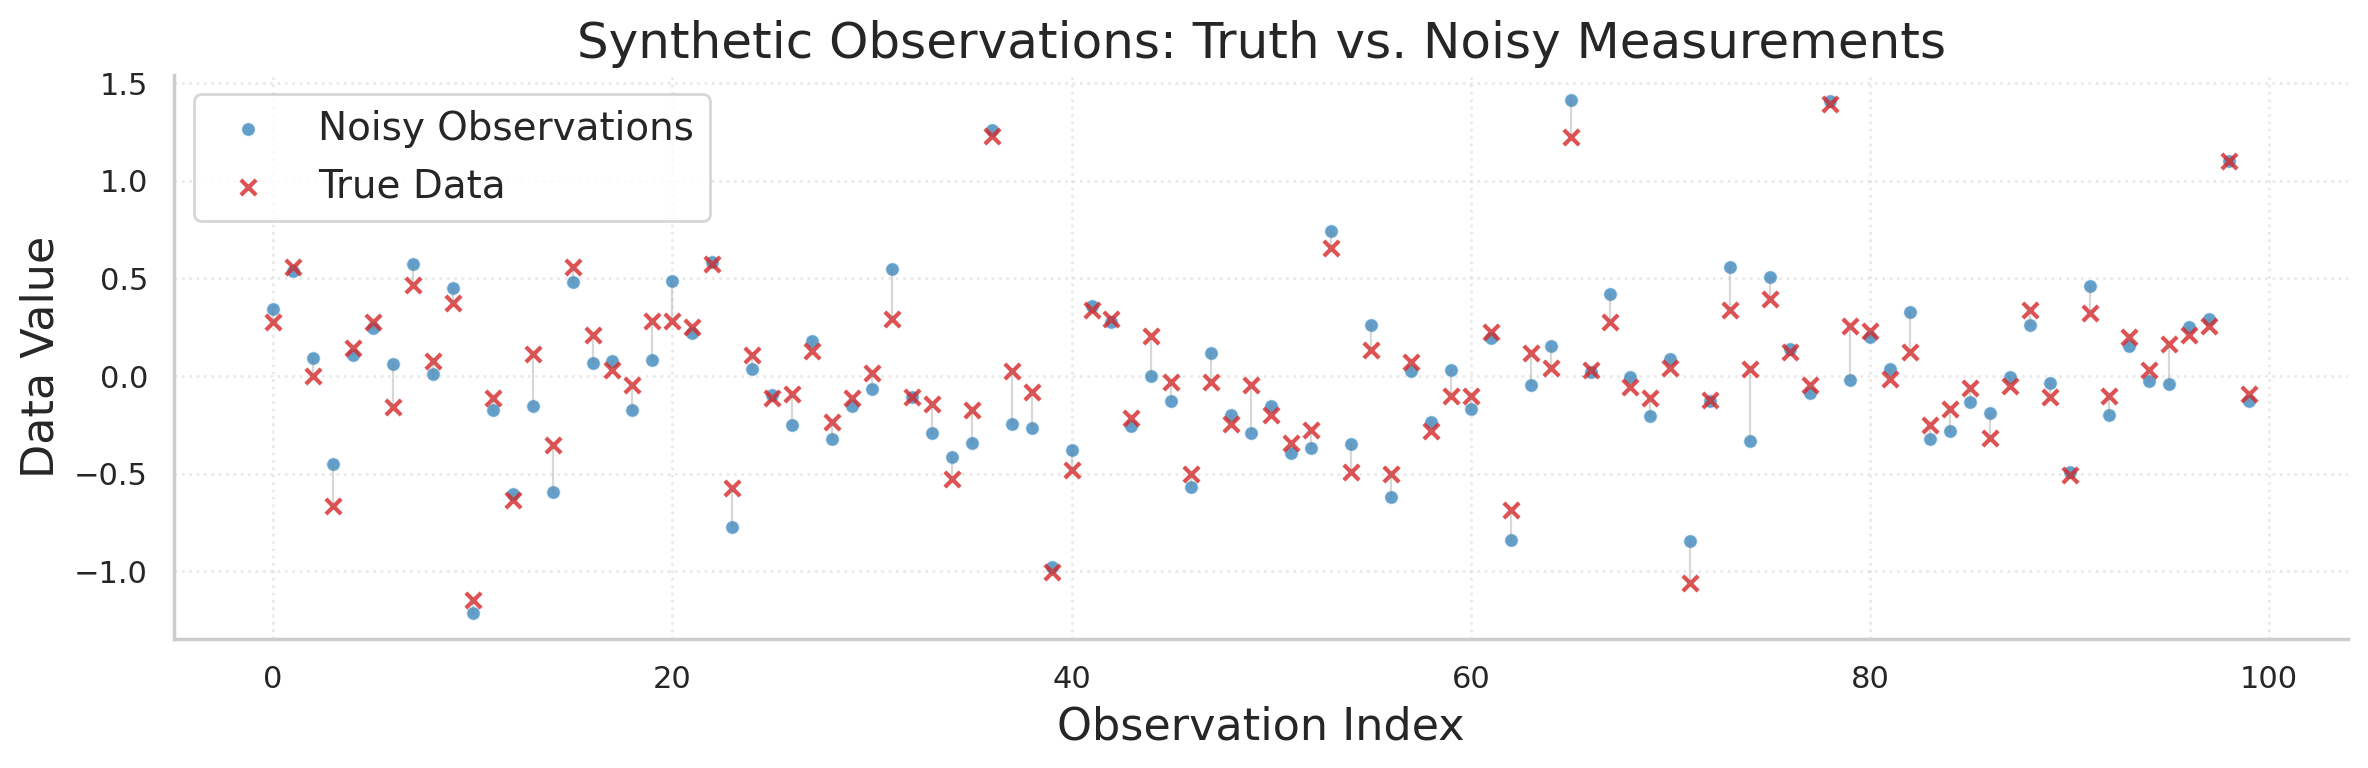

In [6]:
# Create the synthetic true models for vp and vs
m_bar_vp = Function(M_vp, evaluate_callable=lambda x: np.exp(-((x - function_domain.center)/0.5)**2) * np.sin(5 * np.pi * x) + x)
m_bar_vs = Function(M_vs, evaluate_callable=lambda x: np.exp(-((x - function_domain.center)/0.5)**2) * np.sin(10 * np.pi * x) + x)
# Keep a combined representation for the direct sum
m_bar = [m_bar_vp, m_bar_vs]

# Evaluation grid
x = np.linspace(function_domain.a, function_domain.b, 1000)

# True model plots: two stacked subplots (vp on top, vs on bottom)
fig_title = "True Models (vp & vs)"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

sns.set_theme(style="whitegrid", palette="muted", color_codes=True)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), dpi=200, sharex=True)

# Top: vp
axs[0].plot(x, m_bar_vp.evaluate(x), color='tab:red', linewidth=2.5, label=r'$\bar{m}_{vp}(x)$')
axs[0].set_title(r"True Model: $\bar{m}_{vp}(x)$ (Sobolev space)", fontsize=16)
axs[0].set_ylabel('Model Value', fontsize=12)
axs[0].legend(fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.4)

# Bottom: vs
axs[1].plot(x, m_bar_vs.evaluate(x), color='tab:blue', linewidth=2.5, label=r'$\bar{m}_{vs}(x)$')
axs[1].set_title(r"True Model: $\bar{m}_{vs}(x)$ (Sobolev space)", fontsize=16)
axs[1].set_xlabel(r"$x$", fontsize=12)
axs[1].set_ylabel('Model Value', fontsize=12)
axs[1].legend(fontsize=12)
axs[1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()

# Save
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Generate synthetic observations
print("Generating synthetic data...")
d_bar = G(m_bar)  # Clean observations

# Compute noise based on the numeric array
noise_level = 0.1 * np.max(d_bar)
np.random.seed(42)  # For reproducibility
d_tilde = d_bar + np.random.normal(0, noise_level, d_bar.shape)

print(f"Signal-to-noise ratio: {np.max(d_bar) / noise_level:.1f}")
print(f"Number of observations: {len(d_tilde)}")

# Data comparison plot
fig_title = "Synthetic Observations"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
data_indices = np.arange(len(d_bar))

# Plot connection lines between true and noisy data
for i in range(len(d_bar)):
    plt.plot([i, i], [d_bar[i], d_tilde[i]], color='gray', alpha=0.3, linewidth=0.8)

# Plot the data points
plt.scatter(data_indices, d_tilde, label='Noisy Observations',
           color='tab:blue', alpha=0.7, marker='o', s=25, edgecolors='white', linewidths=0.5)
plt.scatter(data_indices, d_bar, label='True Data',
           color='tab:red', alpha=0.8, marker='x', s=30, linewidths=1.5)

plt.xlabel('Observation Index', fontsize=16)
plt.ylabel('Data Value', fontsize=16)
plt.title('Synthetic Observations: Truth vs. Noisy Measurements', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Data Noise Model

### Gaussian Noise Assumption

We model the measurement noise as independent Gaussian with known variance:
$$\bm{\eta} \sim \mathcal{N}(\mathbf{0}, \mathbf{C}_{\mathcal{D}})$$

where $\mathbf{C}_{\mathcal{D}} = \sigma^2 \mathbf{I}$ represents uncorrelated measurement errors. This gives us the data measure:
$$\mu_{\mathcal{D}} = \mathcal{N}(\mathbf{\tilde{d}}, \mathbf{C}_{\mathcal{D}})$$

The choice of diagonal covariance assumes that measurement errors are independent across different data points, which is a common assumption in many practical applications.

In [7]:
# Define data noise covariance
noise_variance = (0.1 * np.max(d_tilde))**2  # 10% of peak signal
C_D_matrix = noise_variance * np.eye(N_d)

print(f"Data noise standard deviation: {np.sqrt(noise_variance):.4f}")
print(f"Relative noise level: {100 * np.sqrt(noise_variance) / np.max(d_tilde):.1f}%")

# Create data NOISE measure (zero mean) for LinearForwardProblem
# This represents the noise model: η ~ N(0, C_D)
gaussian_D_noise = GaussianMeasure.from_covariance_matrix(D, C_D_matrix, expectation=np.zeros(N_d))

# Create data measure (with observed data mean) for visualization
# This represents the likelihood: d̃ | m ~ N(G(m), C_D)
gaussian_D = GaussianMeasure.from_covariance_matrix(D, C_D_matrix, expectation=d_tilde)

Data noise standard deviation: 0.1413
Relative noise level: 10.0%


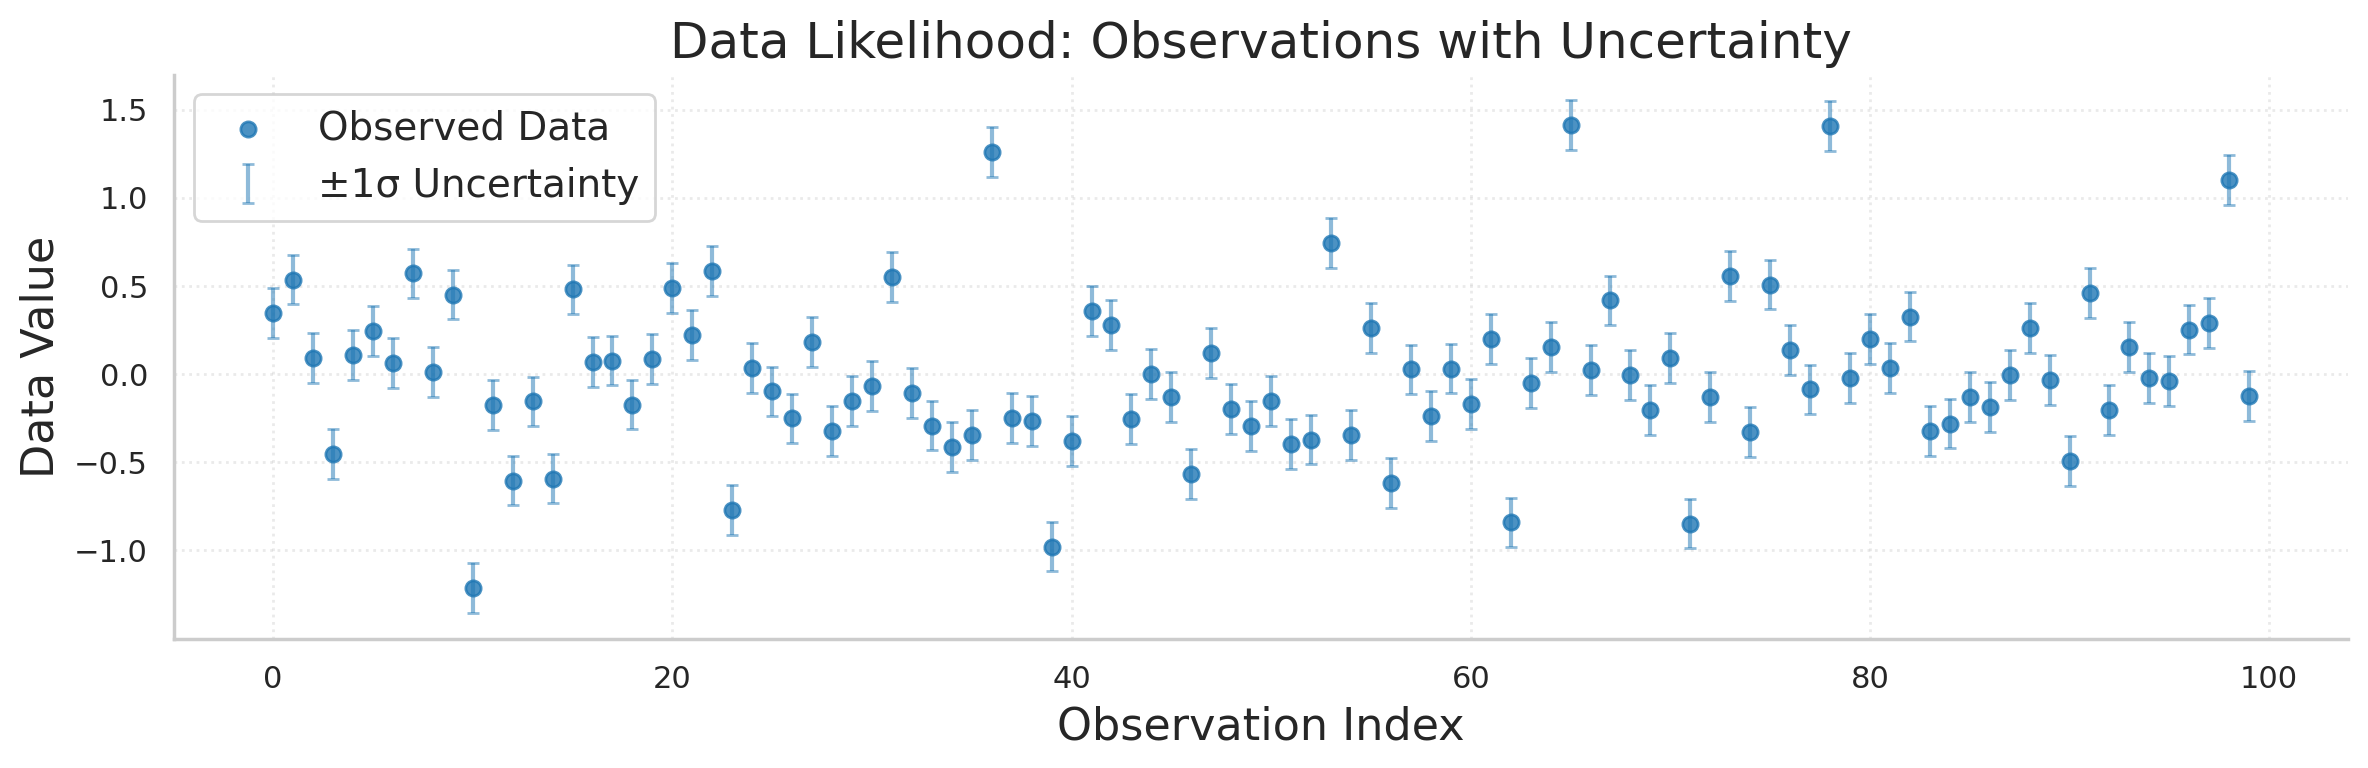

In [8]:
# Visualize the data measure (observed data with uncertainty)
# Note: We use gaussian_D (with data mean) for visualization, not gaussian_D_error (zero mean)
mean_values = gaussian_D.expectation
std_values = np.sqrt(noise_variance)

fig_title = "Data Likelihood Distribution"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 4), dpi=200)
data_indices = np.arange(len(mean_values))

plt.scatter(data_indices, mean_values, label='Observed Data', color='tab:blue', alpha=0.8, s=30)
plt.errorbar(data_indices, mean_values, yerr=std_values, fmt='none',
            color='tab:blue', alpha=0.5, capsize=2, capthick=1,
            label='±1σ Uncertainty')

plt.title("Data Likelihood: Observations with Uncertainty", fontsize=18)
plt.xlabel('Observation Index', fontsize=16)
plt.ylabel('Data Value', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## SOLA Operator Construction

### Computing the Optimal Operator

We now compute the optimal SOLA operator $\mathbf{X}$ and related quantities:

1. **Gram Operator**: $\Lambda = GG^*$ (Gram matrix of the forward operator)
2. **Regularized Gram Operator**: $W^{-1} = (\Lambda + \mathbf{C}_{\mathcal{D}})^{-1}$
3. **Generalized inverse**: $G^{\dagger} = G^* W^{-1}$ 
4. **SOLA operator**: $\mathbf{X} = \mathcal{T} G^{\dagger}$

The regularized gram operator $W^{-1}$ incorporates both the ill-conditioning of the forward problem and the data noise, providing a numerically stable solution.

In [9]:
# Compute SOLA operator components
print("Computing SOLA operator...")

# Step 1: Compute normal operator Λ = GG*
print("  - Computing Gram matrix...")
Lambda = G @ G.adjoint

# Step 2: Solve (Λ + C_D)^{-1} using Cholesky decomposition
print("  - Computing regularized gram operator...")
cholesky_solver = CholeskySolver(galerkin=True, parallel=True, n_jobs=8)
W_inv = cholesky_solver(Lambda + gaussian_D.covariance)

# Step 3: Compute generalized inverse G† = G* W^{-1}
print("  - Computing generalized inverse...")
G_inv = G.adjoint @ W_inv

# Step 4: Compute SOLA operator X = T G†
print("  - Computing SOLA operator...")
X = T @ G_inv

print("✓ SOLA operator construction complete!")

Computing SOLA operator...
  - Computing Gram matrix...
  - Computing regularized gram operator...
  - Computing generalized inverse...
  - Computing SOLA operator...
✓ SOLA operator construction complete!


## Model Reconstruction (Optional)

### Least-Norm Solution

Although our primary goal is property inference rather than full model reconstruction, we can still compute the model that corresponds to our estimate. This is the least-norm solution:

$$\tilde{m} = G^{\dagger}(\mathbf{\tilde{d}})$$

where $G^{\dagger}$ is the regularized generalized inverse we computed above. This model represents the smoothest solution consistent with the noisy data.

In [10]:
# Compute the least-norm model reconstruction from noisy data
print("Computing model reconstruction...")
m_tilde = G_inv(d_tilde)
M.norm(m_tilde)
# Compute model misfit in the Sobolev norm
model_misfit = M.norm(M.subtract(m_tilde, m_bar))
relative_model_misfit = 100 * model_misfit / M.norm(m_bar)

print("✓ Model reconstruction computed")
print(f"Reconstruction components: {len(m_tilde)}")
print(f"Model misfit (Sobolev norm): {model_misfit:.4f}")
print(f"Relative model misfit: {relative_model_misfit:.1f}%")


Computing model reconstruction...
✓ Model reconstruction computed
Reconstruction components: 2
Model misfit (Sobolev norm): 22.7570
Relative model misfit: 76.4%


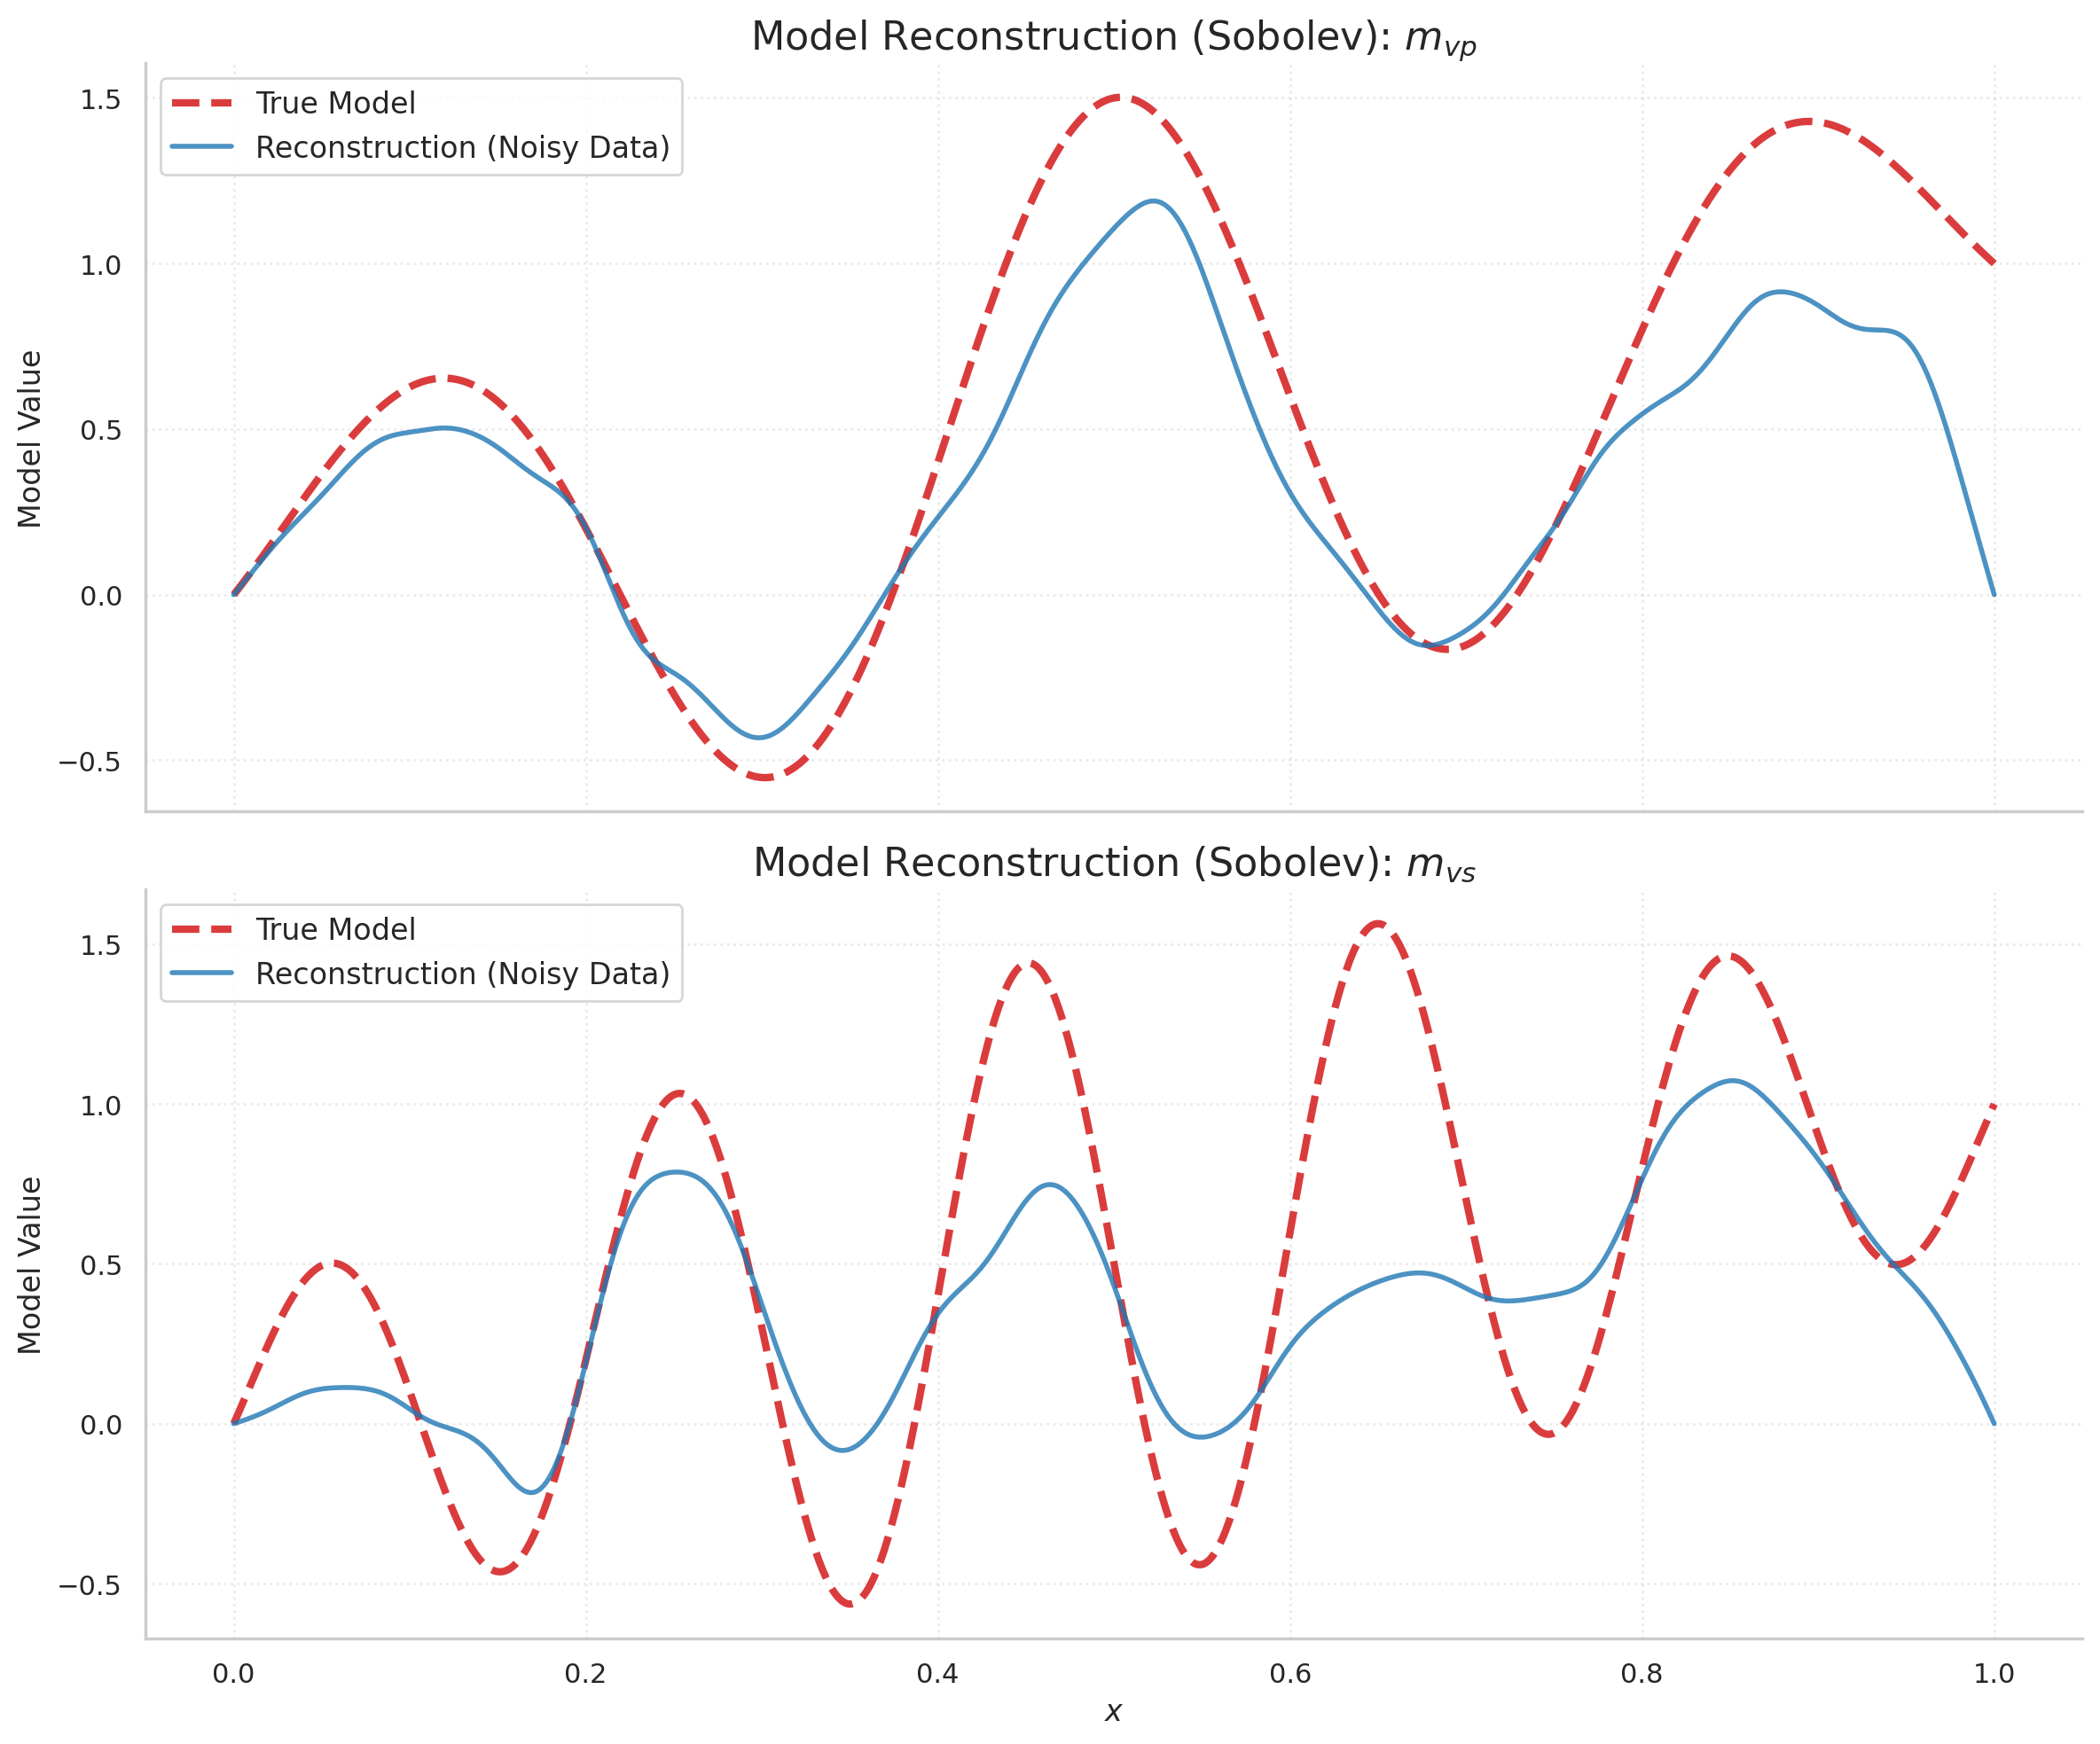


Data misfit: 1.8360
Relative data misfit: 41.3%


In [11]:
# Model reconstruction plot (for direct sum of Sobolev spaces)
fig_title = "Model Reconstruction Comparison"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

sns.set_theme(style="whitegrid", palette="muted", color_codes=True)

# Two components: vp and vs
fig, axs = plt.subplots(2, 1, figsize=(12, 10), dpi=200, sharex=True)

# Top: vp reconstruction
m_rec_vp = m_tilde[0]  # First component
axs[0].plot(x, m_bar_vp.evaluate(x), label='True Model', linestyle='--',
         color='tab:red', linewidth=3, alpha=0.9)
axs[0].plot(x, m_rec_vp.evaluate(x), label='Reconstruction (Noisy Data)',
         color='tab:blue', alpha=0.8, linewidth=2)
axs[0].set_title(r'Model Reconstruction (Sobolev): $m_{vp}$', fontsize=16)
axs[0].set_ylabel('Model Value', fontsize=12)
axs[0].legend(fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.4)

# Bottom: vs reconstruction
m_rec_vs = m_tilde[1]  # Second component
axs[1].plot(x, m_bar_vs.evaluate(x), label='True Model', linestyle='--',
         color='tab:red', linewidth=3, alpha=0.9)
axs[1].plot(x, m_rec_vs.evaluate(x), label='Reconstruction (Noisy Data)',
         color='tab:blue', alpha=0.8, linewidth=2)
axs[1].set_title(r'Model Reconstruction (Sobolev): $m_{vs}$', fontsize=16)
axs[1].set_xlabel(r'$x$', fontsize=12)
axs[1].set_ylabel('Model Value', fontsize=12)
axs[1].legend(fontsize=12)
axs[1].grid(True, linestyle=':', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Compute data fit
data_misfit = D.norm(G(m_tilde) - d_tilde)
relative_data_misfit = 100 * data_misfit / D.norm(d_tilde)
print(f"\nData misfit: {data_misfit:.4f}")
print(f"Relative data misfit: {relative_data_misfit:.1f}%")

## Property Inference with Uncertainty

### Push-forward of Data Measure

We obtain our property estimates by pushing the data measure forward through the SOLA operator:

$$\mu_{\mathcal{P}} = \mathbf{X}_* \mu_{\mathcal{D}}$$

This automatically computes:
- **Property mean**: $\mathbf{\tilde{p}} = \mathbf{X}(\mathbf{\tilde{d}})$
- **Property covariance**: $\mathbf{C}_{\mathcal{P}} = \mathbf{X} \mathbf{C}_{\mathcal{D}} \mathbf{X}^*$

The resulting measure $\mu_{\mathcal{P}} = \mathcal{N}(\mathbf{\tilde{p}}, \mathbf{C}_{\mathcal{P}})$ provides both point estimates and uncertainty quantification for each property.

In [12]:
# Push forward the data measure through X to get property measure
print("Computing property measure via push-forward...")
# This automatically computes: mean = X(data_mean), covariance = X @ C_D @ X.adjoint
property_measure = gaussian_D.affine_mapping(operator=X)

# Compute true properties for comparison
p_bar = T(m_bar)  # true property values

print(f"Property measure computed for {N_p} target locations")
print(f"Property mean range: [{property_measure.expectation.min():.3f}, {property_measure.expectation.max():.3f}]")
print(f"True property range: [{p_bar.min():.3f}, {p_bar.max():.3f}]")

Computing property measure via push-forward...
Property measure computed for 20 target locations
Property mean range: [-0.270, 0.945]
True property range: [-0.381, 1.332]


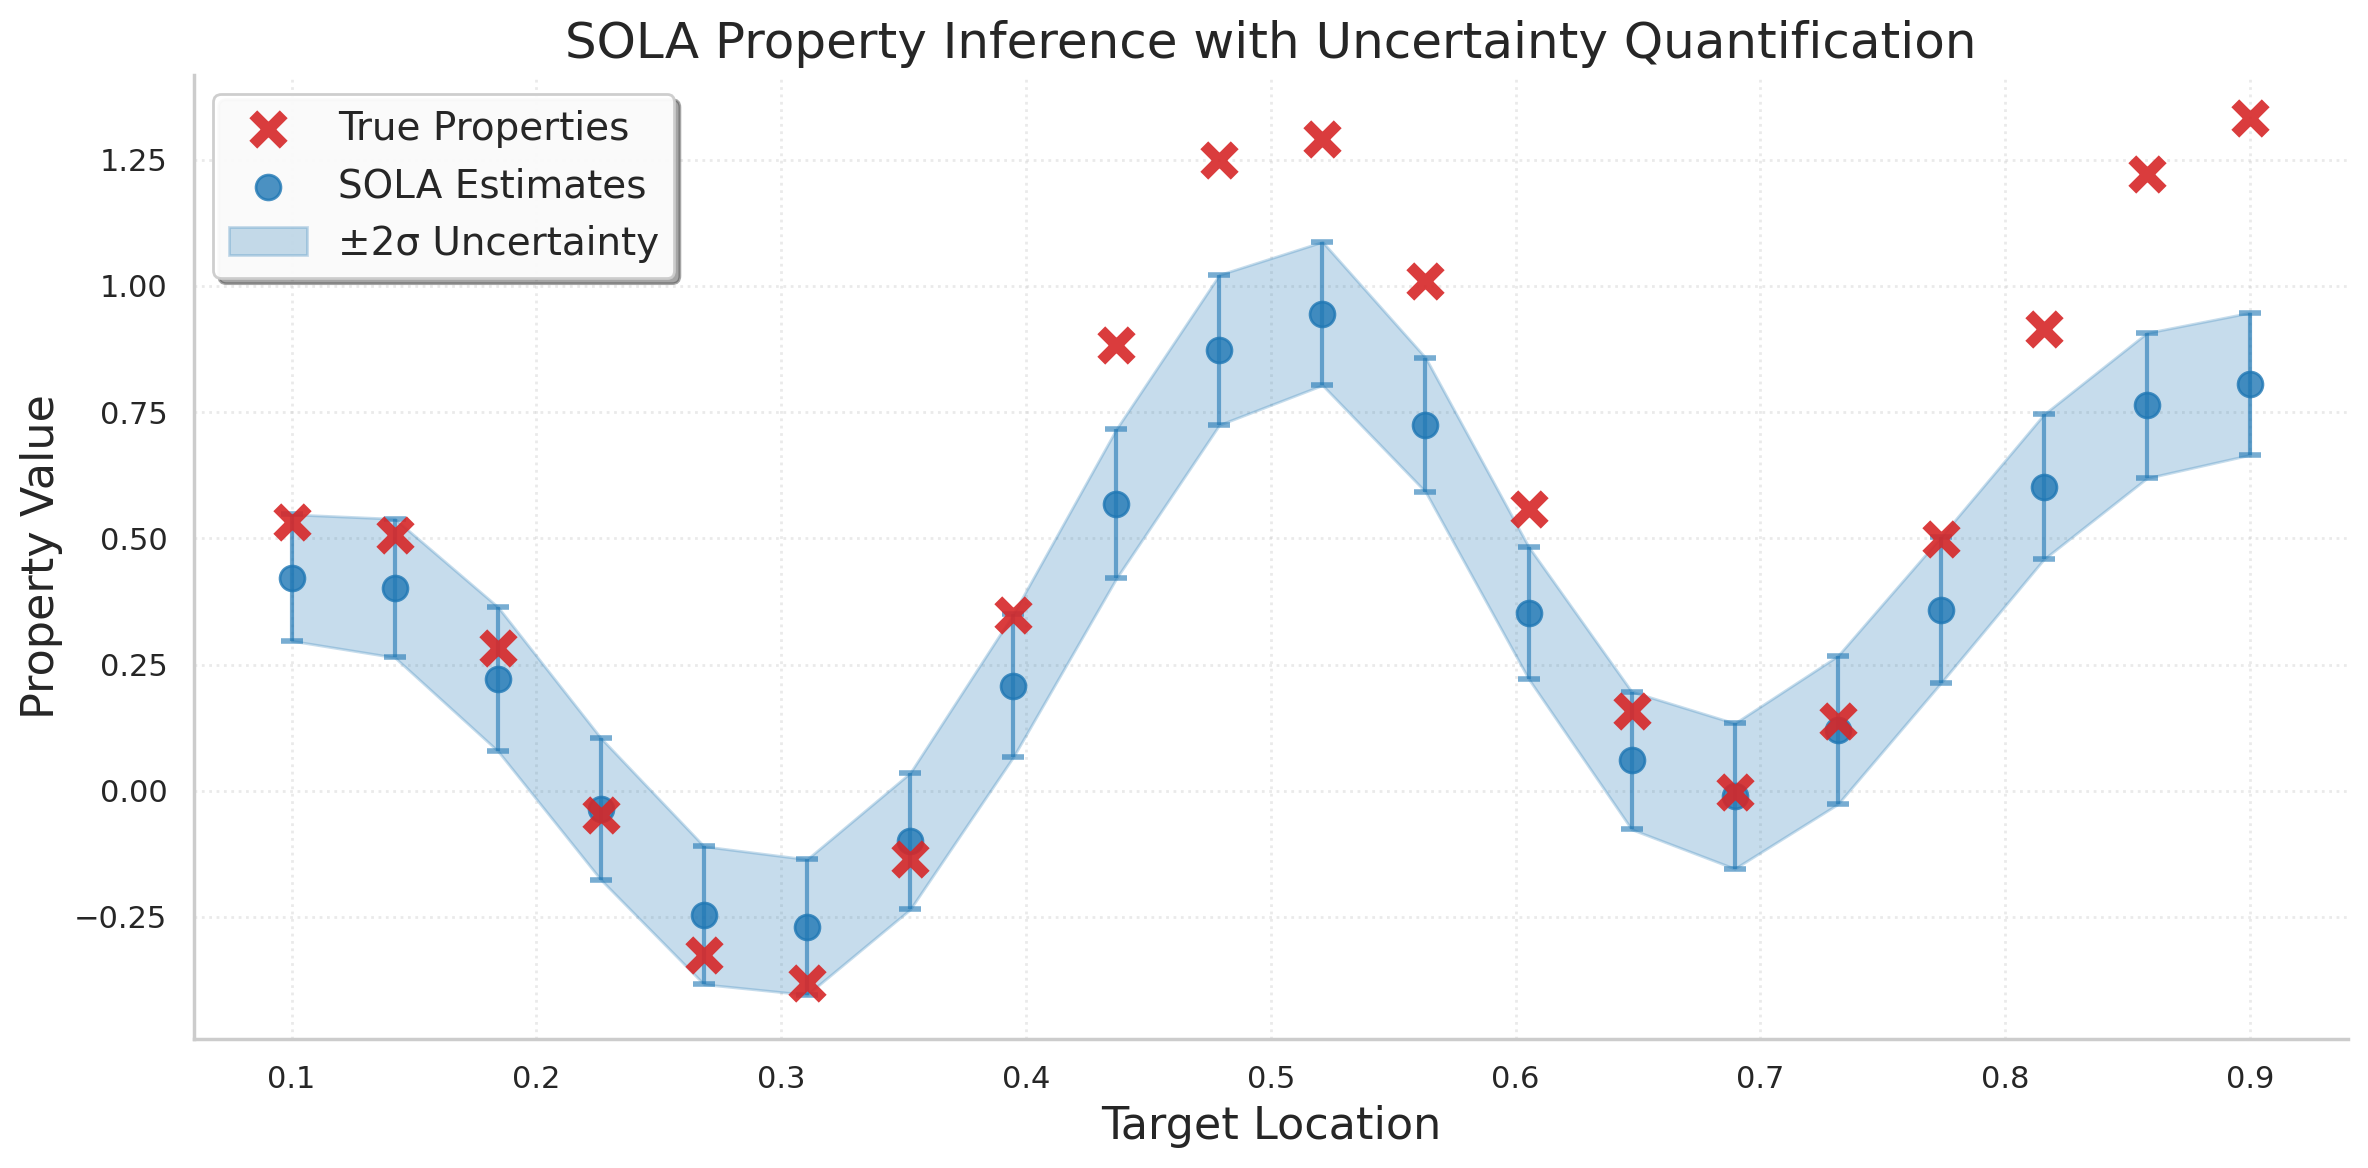


PROPERTY INFERENCE SUMMARY
Properties within ±2σ: 12/20 (60.0%)
Mean absolute error: 0.1872
RMS error: 0.2412
Max error: 0.5256
Average uncertainty (2σ): 0.1398


In [13]:
# Visualize property measure with uncertainty quantification
fig_title = "Property Inference Results"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 6), dpi=200)

# Get the mean from the property measure
p_mean = property_measure.expectation

# Compute standard deviations from the covariance matrix
p_std = np.zeros(N_p)
P_cov_mat = property_measure.covariance.matrix(dense=True, parallel=True, n_jobs=8)
p_std = np.sqrt(np.diag(P_cov_mat))

# Plot with enhanced styling
plt.scatter(centers, p_bar, label='True Properties',
           color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10)
plt.scatter(centers, p_mean, label='SOLA Estimates',
           color='tab:blue', marker='o', s=80, alpha=0.8, zorder=5)

# Add uncertainty bands (mean ± 2σ)
plt.fill_between(centers, p_mean - 2*p_std, p_mean + 2*p_std,
                alpha=0.25, color='tab:blue', label='±2σ Uncertainty', zorder=1)
plt.errorbar(centers, p_mean, yerr=2*p_std, fmt='none',
            ecolor='tab:blue', alpha=0.6, capsize=4, capthick=2, zorder=3)

plt.title('SOLA Property Inference with Uncertainty Quantification', fontsize=18)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Quantitative assessment
property_errors = np.abs(p_mean - p_bar)
within_2sigma = np.sum(property_errors <= 2*p_std)

print("\n" + "="*50)
print("PROPERTY INFERENCE SUMMARY")
print("="*50)
print(f"Properties within ±2σ: {within_2sigma}/{len(p_bar)} ({100*within_2sigma/len(p_bar):.1f}%)")
print(f"Mean absolute error: {np.mean(property_errors):.4f}")
print(f"RMS error: {np.sqrt(np.mean(property_errors**2)):.4f}")
print(f"Max error: {np.max(property_errors):.4f}")
print(f"Average uncertainty (2σ): {np.mean(2*p_std):.4f}")
print("="*50)

## Unimodular Constraint Enhancement

### Imposing Unimodularity

The unconstrained SOLA solution may not preserve certain physical constraints. A common requirement is **unimodularity**: the property operator should correctly recover uniform fields. Specifically, if $m(x) = 1$ everywhere, then each property should equal 1.

We impose this constraint by modifying the SOLA operator:
$$\mathbf{X}_{\text{uni}} = \mathbf{X} - \frac{(\mathbf{X}(\mathbf{v}) - \mathbf{w})}{\beta} \mathbf{u}^T$$

where:
- $\mathbf{v} = G(\mathbf{1})$ (forward operator applied to constant field)
- $\mathbf{w} = \mathbf{1}$ (desired output for constant field)  
- $\mathbf{u} = W^{-1}(\mathbf{v})$ (weighted projection vector)
- $\beta = \mathbf{v}^T \mathbf{u}$ (normalization factor)

This ensures that $\mathbf{X}_{\text{uni}}(G(\mathbf{1})) = \mathbf{1}$, preserving the physical interpretation of the properties.

In [14]:
# Imposing unimodularity constraint
print("Computing unimodular SOLA operator...")

# Step 1: Create constant unit functions for each component
M_one_vp = Function(M_vp, evaluate_callable=lambda x: np.ones_like(x))
M_one_vs = Function(M_vs, evaluate_callable=lambda x: np.zeros_like(x))  # Zero for vs component

# Step 2: Apply forward operator to get v = G([1, 0])
v = G([M_one_vp, M_one_vs])

# Step 3: Define desired output for constant field
w = np.ones(N_p)

# Step 4: Compute weighted projection u = W^{-1}(v)
u = W_inv(v)

# Step 5: Compute normalization factor β = v^T u
beta = D.inner_product(v, u)

# Step 6: Construct correction term
correction = LinearOperator.from_matrix(D, P, np.outer((X(v) - w) / beta, u))

# Step 7: Apply correction to get unimodular operator
X_unimodular = X - correction

print(f"Unimodularity check: X(G(1)) = {X(v)}")
print(f"Unimodular check: X_uni(G(1)) = {X_unimodular(v)}")
print("✓ Unimodular constraint applied!")

# Compute property measure with unimodular operator
property_measure_unimodular = gaussian_D.affine_mapping(operator=X_unimodular)

Computing unimodular SOLA operator...
Unimodularity check: X(G(1)) = [0.84837236 0.87630256 0.86582227 0.87006998 0.88143928 0.88577556
 0.86865459 0.83272778 0.80210664 0.80736377 0.83417743 0.86430669
 0.86526975 0.84448844 0.80890328 0.79943372 0.80684734 0.79189662
 0.72559535 0.62752958]
Unimodular check: X_uni(G(1)) = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
✓ Unimodular constraint applied!


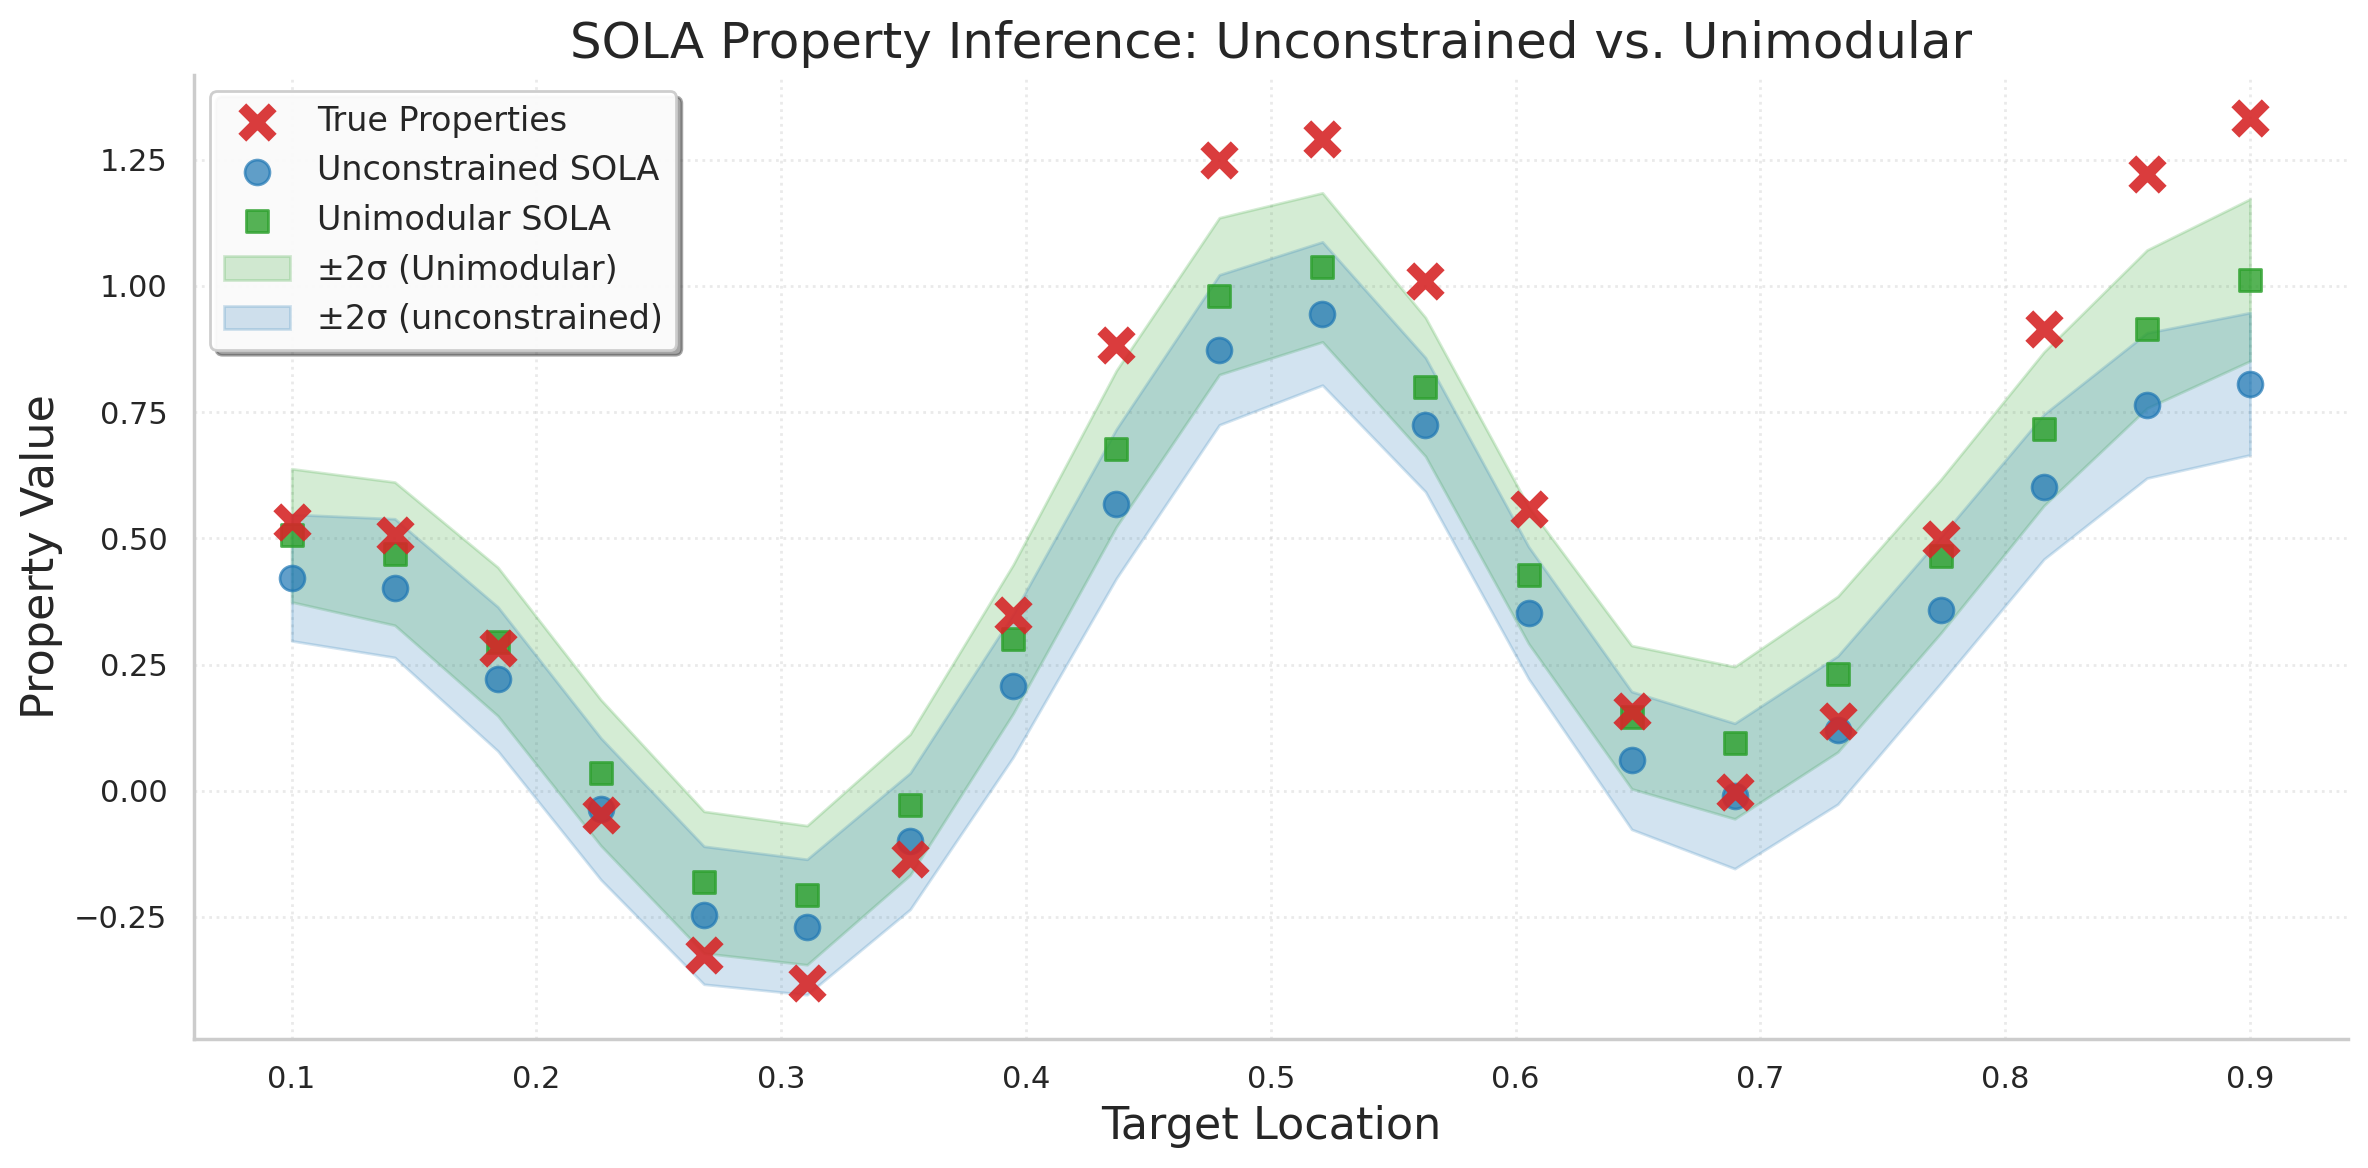


UNCONSTRAINED vs. UNIMODULAR SOLA COMPARISON
Unconstrained SOLA - Mean absolute error: 0.1872
Unimodular SOLA - Mean absolute error: 0.1383
Unconstrained SOLA - RMS error: 0.2412
Unimodular SOLA - RMS error: 0.1689
Improvement ratio: 1.35


In [15]:
# Visualize comparison between unconstrained and unimodular SOLA
fig_title = "SOLA Unconstrained vs Unimodular Comparison"
filename = os.path.join(figures_folder, fig_title.replace(" ", "_").lower() + ".png")

plt.figure(figsize=(12, 6), dpi=200)

# Get means from both property measures
p_mean_unconstrained = property_measure.expectation
p_mean_unimodular = property_measure_unimodular.expectation

# Compute unconstrained deviations (assume similar uncertainty structure)
p_std_unconstrained = np.zeros(N_p)
p_std_unimodular = np.zeros(N_p)

P_cov_mat_unconstrained = property_measure.covariance.matrix(dense=True, parallel=True, n_jobs=8)
P_cov_mat_unimodular = property_measure_unimodular.covariance.matrix(dense=True, parallel=True, n_jobs=8)

p_std_unconstrained = np.sqrt(np.diag(P_cov_mat_unconstrained))
p_std_unimodular = np.sqrt(np.diag(P_cov_mat_unimodular))
# Plot comparisons
plt.scatter(centers, p_bar, label='True Properties',
           color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10)
plt.scatter(centers, p_mean_unconstrained, label='Unconstrained SOLA',
           color='tab:blue', marker='o', s=80, alpha=0.7, zorder=6)
plt.scatter(centers, p_mean_unimodular, label='Unimodular SOLA',
           color='tab:green', marker='s', s=60, alpha=0.8, zorder=5)

# Add uncertainty bands for unimodular SOLA
plt.fill_between(centers, p_mean_unimodular - 2*p_std_unimodular, p_mean_unimodular + 2*p_std_unimodular,
                alpha=0.2, color='tab:green', label='±2σ (Unimodular)', zorder=1)

# Add uncertainty bands for unconstrained SOLA
plt.fill_between(centers, p_mean_unconstrained - 2*p_std_unconstrained, p_mean_unconstrained + 2*p_std_unconstrained,
                alpha=0.2, color='tab:blue', label='±2σ (unconstrained)', zorder=1)



plt.title('SOLA Property Inference: Unconstrained vs. Unimodular', fontsize=18)
plt.xlabel('Target Location', fontsize=16)
plt.ylabel('Property Value', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

# Quantitative comparison
errors_unconstrained = np.abs(p_mean_unconstrained - p_bar)
errors_unimodular = np.abs(p_mean_unimodular - p_bar)

print("\n" + "="*60)
print("UNCONSTRAINED vs. UNIMODULAR SOLA COMPARISON")
print("="*60)
print(f"Unconstrained SOLA - Mean absolute error: {np.mean(errors_unconstrained):.4f}")
print(f"Unimodular SOLA - Mean absolute error: {np.mean(errors_unimodular):.4f}")
print(f"Unconstrained SOLA - RMS error: {np.sqrt(np.mean(errors_unconstrained**2)):.4f}")
print(f"Unimodular SOLA - RMS error: {np.sqrt(np.mean(errors_unimodular**2)):.4f}")
print(f"Improvement ratio: {np.mean(errors_unconstrained)/np.mean(errors_unimodular):.2f}")
print("="*60)

## Resolution Kernels Analysis

SOLA solutions must be interpreted through the approximation mapping $\mathcal A$. Just like we have target kernels associated with the property mapping $\mathcal T$, we also have resolving kernels associated with the approximate mapping $\mathcal A$. Given that
$$
\mathcal A = XG = \langle \sum_i X_{ki} K_i, \cdot \rangle_{\mathcal M} = \langle A_k, \cdot \rangle_{\mathcal M}
$$
we identify the resolving kernels as 
$$
A_k = \sum_i X_{ki} K_i
$$.
These resolving kernels express visually the meaning of each $p_k$. 

/tmp/ipykernel_15867/3525546177.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1.0])


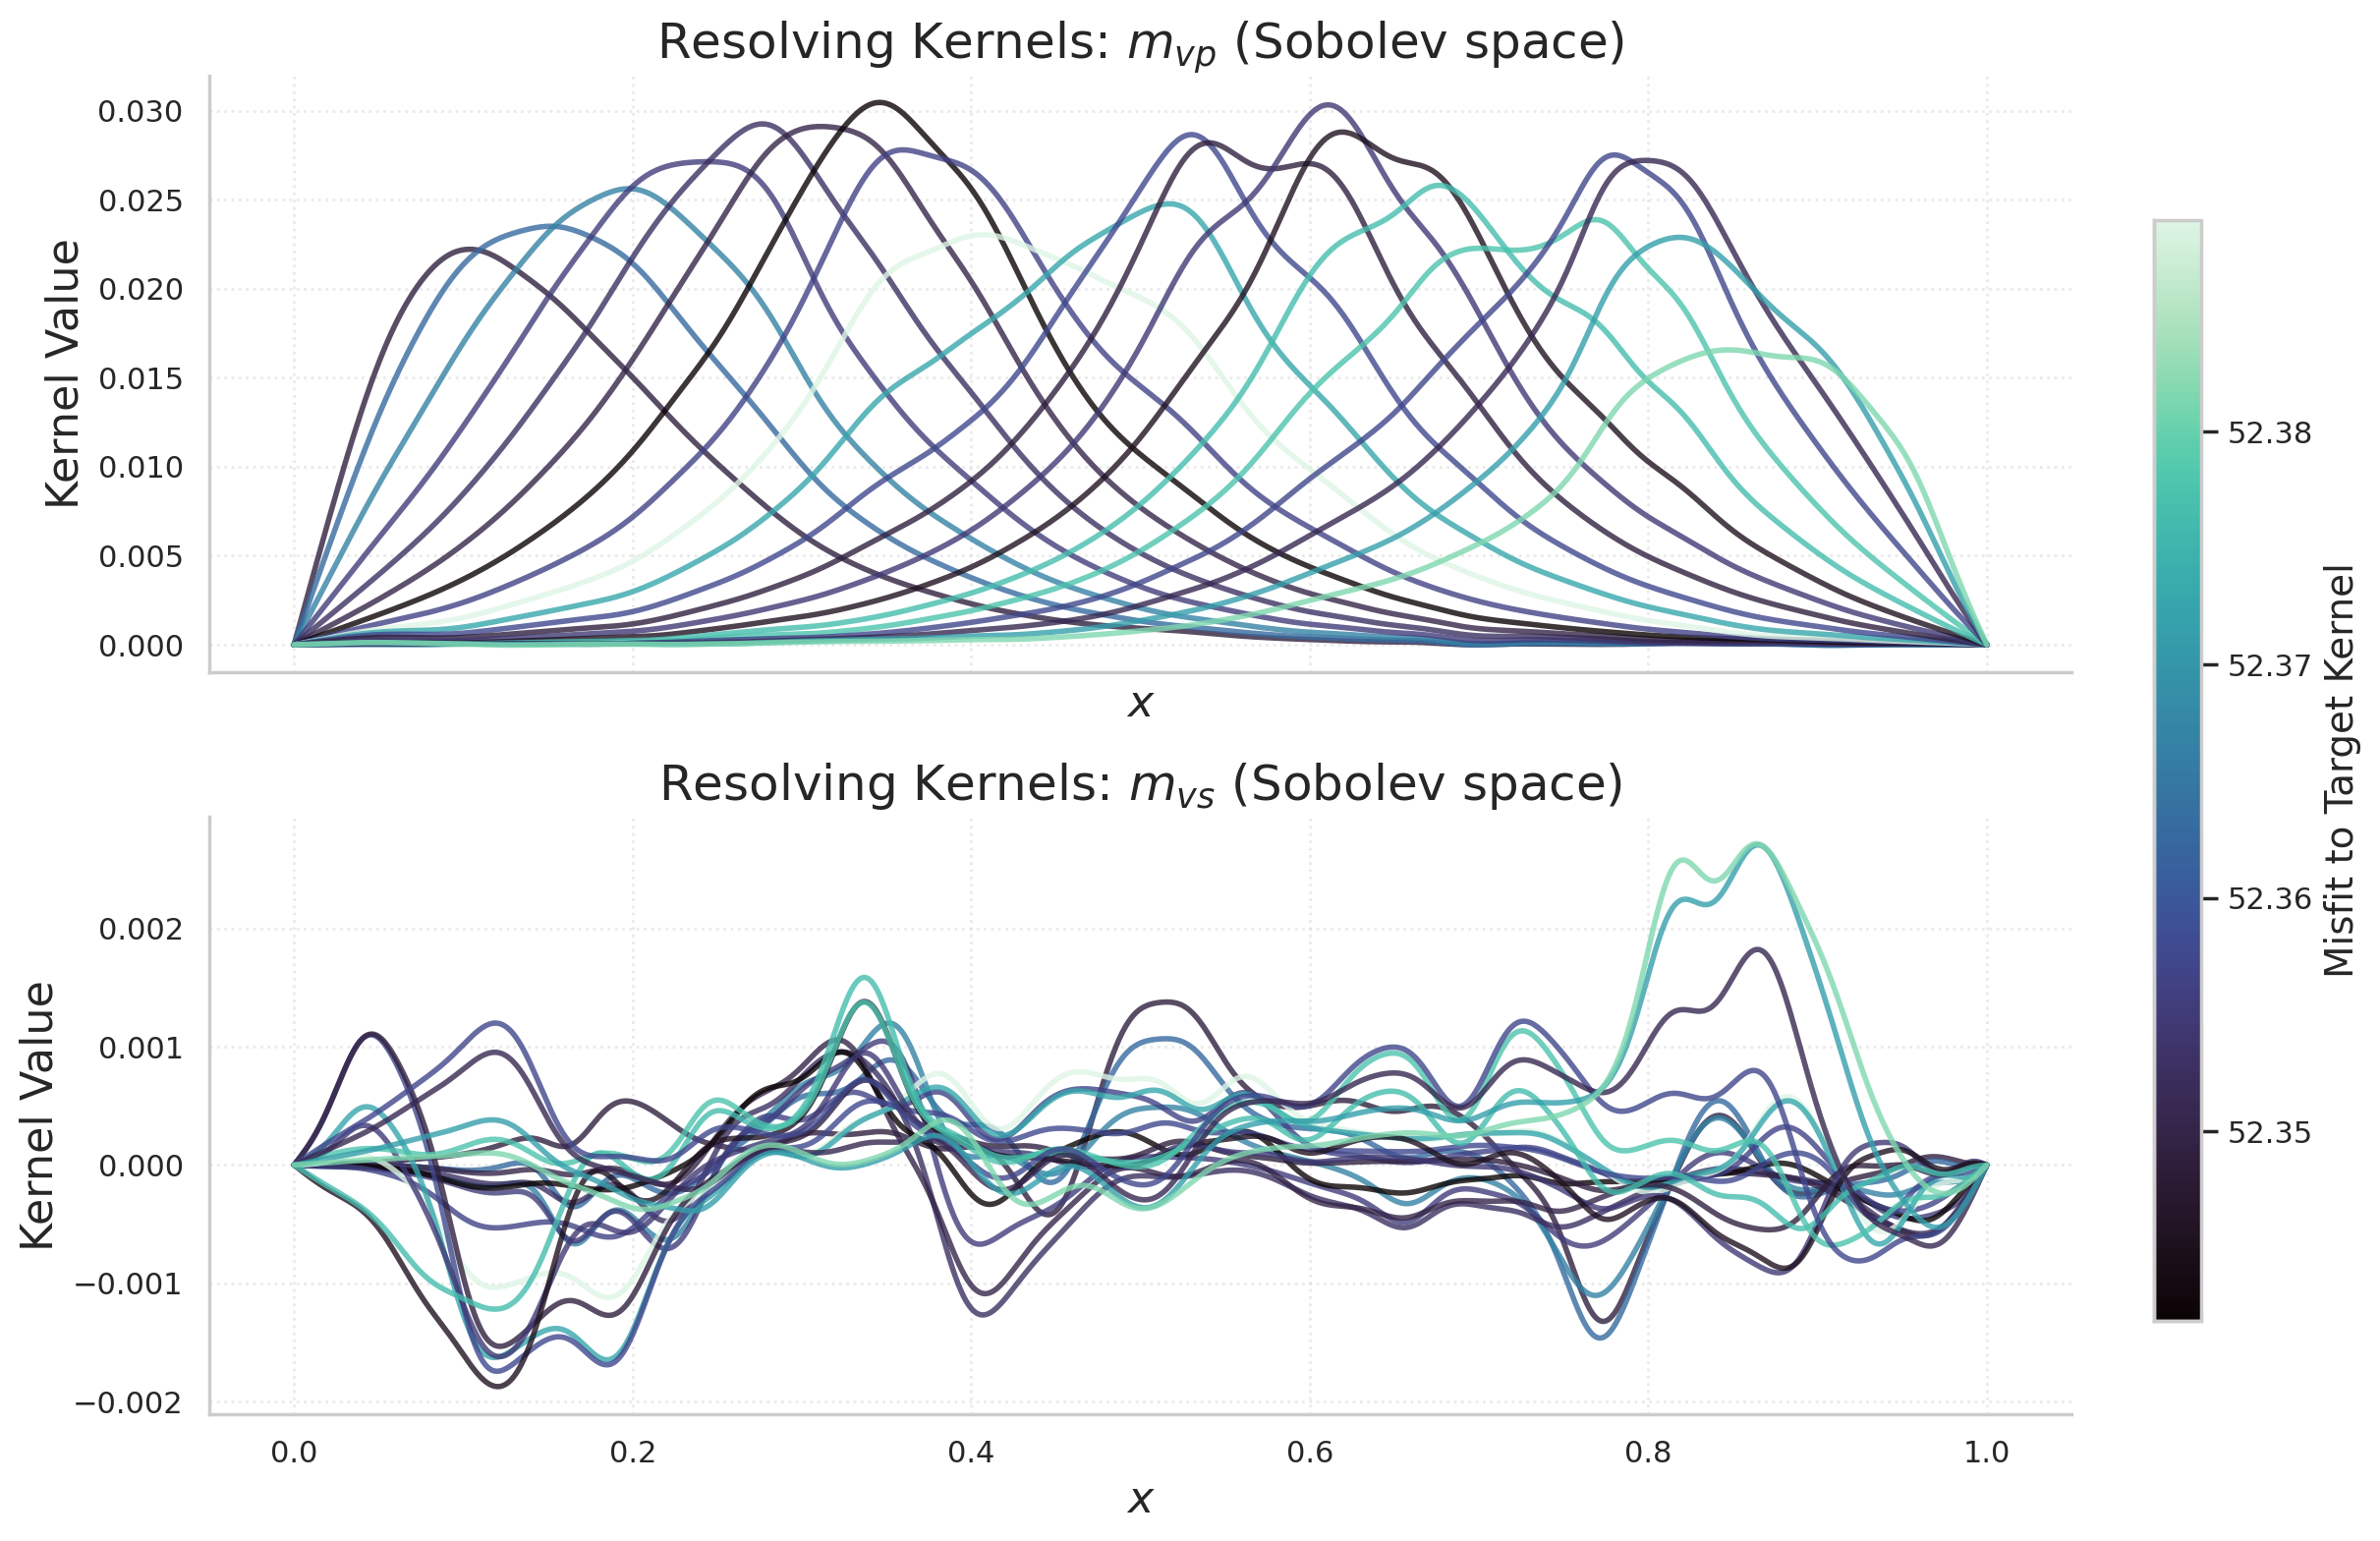


✓ Resolving kernels analysis complete!
Misfit range: [52.3419, 52.3891]
Mean misfit: 52.3609


In [16]:
from matplotlib import cm

A_adjoint = (X @ G).adjoint

cp = np.zeros(N_p)

# Create a colormap based on misfit between resolving and target kernels
misfits = np.zeros(N_p)

# Compute misfit for each resolving kernel
for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)

    # Get corresponding target kernel
    target_vp = T_vp.get_kernel(i)
    target_vs = T_vs.get_kernel(i)

    # Compute misfit between resolving kernel and target kernel
    misfit = M.norm(M.subtract(A_i, [target_vp, target_vs]))
    misfits[i] = misfit

    cp[i] = 0

# Normalize misfits for colormap
norm = plt.Normalize(misfits.min(), misfits.max())
cmap = plt.colormaps.get_cmap("mako")

# Create subplots for each component (one per direct-sum space)
n_axes = len(M._spaces)
fig, axs = plt.subplots(n_axes, 1, figsize=(12, 8), dpi=200, sharex=True)
if n_axes == 1:
    axs = [axs]

# Set labels/titles for each axis
axs[0].set_title("Resolving Kernels: $m_{vp}$ (Sobolev space)", fontsize=18)
axs[1].set_title("Resolving Kernels: $m_{vs}$ (Sobolev space)", fontsize=18)
for ax in axs:
    ax.set_xlabel(r"$x$", fontsize=16)
    ax.set_ylabel("Kernel Value", fontsize=16)

# Plot each resolving kernel component onto its corresponding axis
for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)
    for j, A_i_j in enumerate(A_i):
        color = cmap(norm(misfits[i]))
        axs[j].plot(x, A_i_j.evaluate(x), alpha=0.8, linewidth=2, color=color)
    cp[i] = 0

# Create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Reserve space on the right for a single shared colorbar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Misfit to Target Kernel", fontsize=14)

# Grid on both axes and finalize layout
for ax in axs:
    ax.grid(True, linestyle=':', alpha=0.4)
sns.despine()
fig.subplots_adjust(right=0.9)
fig.tight_layout(rect=[0, 0, 0.9, 1.0])
fig.savefig(os.path.join(figures_folder, "resolving_kernels.png"), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(figures_folder, "resolving_kernels.pdf"), bbox_inches='tight')
plt.show()

print(f"\n✓ Resolving kernels analysis complete!")
print(f"Misfit range: [{misfits.min():.4f}, {misfits.max():.4f}]")
print(f"Mean misfit: {misfits.mean():.4f}")
